In [39]:
import os
import numpy as np
import matplotlib.patches as mpatches
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.spatial import HalfspaceIntersection, ConvexHull
from scipy.optimize import linprog
from scipy.stats import beta, gaussian_kde
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

os.makedirs("figures_main", exist_ok=True)
os.makedirs("figures_appendix", exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 11, "font.family": "serif",
    "axes.titlesize": 11, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 9.5,
    "axes.linewidth": 0.8, "axes.edgecolor": "0.3",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "legend.frameon": True, "legend.framealpha": 0.9, "legend.edgecolor": "0.8",
    "mathtext.fontset": "cm",
    "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
})

COLORS = {
    "unconstrained": "#4477AA", "mean": "#CC3311", "moment": "#AA3377",
    "median": "#228833", "conditional": "#EE7733", "point": "#000000",
}
print("Setup complete.")

Setup complete.


In [2]:
df = pd.read_csv("cps2020_v1.csv")
df = df[(df["WSAL_VAL"] > 0) & (df["wor_status"] == "Employed")].copy()
df["ystar"] = df["WSAL_VAL"].to_numpy(float) / 1000.0
df["educ"]  = df["educ_numeric"].to_numpy(float)
df["race"]  = np.where(df["PRDTRACE"].to_numpy(int) == 1, 1, 2)
df["age"]   = df["A_AGE"].to_numpy(float)
df = df[df["ystar"] <= df["ystar"].quantile(0.99)].copy()

n     = len(df)
ystar = df["ystar"].to_numpy(float)
educ  = df["educ"].to_numpy(float)
race  = df["race"].to_numpy(float)
age   = df["age"].to_numpy(float)

X    = np.column_stack([np.ones(n), educ])
Q    = X.T @ X / n
Qinv = np.linalg.inv(Q)

print(f"n = {n}")
eigs = np.linalg.eigvalsh(Q)
assert np.all(eigs > 0), "Assumption 1 violated"
print("Assumption 1 (Q positive definite): CONFIRMED")

n = 22397
Assumption 1 (Q positive definite): CONFIRMED


In [3]:
a = ystar.min() - 1e-6
b = ystar.max() + 1e-6
rng = np.random.default_rng(2026)
p1 = beta.rvs(2, 2, size=n, random_state=rng)
p2 = beta.rvs(2, 2, size=n, random_state=rng)
y_sorted = np.sort(ystar)
Uanchor = np.quantile(y_sorted, np.minimum(p1, p2))
Vanchor = np.quantile(y_sorted, np.maximum(p1, p2))
below = ystar <= Uanchor
mid   = (ystar > Uanchor) & (ystar <= Vanchor)
yL = np.where(below, a, np.where(mid, Uanchor, Vanchor))
yU = np.where(below, Uanchor, np.where(mid, Vanchor, b))
Delta = yU - yL

assert np.all(yL <= ystar + 1e-9) and np.all(ystar <= yU + 1e-9)
assert np.all(np.isfinite(yL)) and np.all(np.isfinite(yU))
assert np.all(yL > 0)
print(f"containment and finiteness: CONFIRMED. min(yL) = {yL.min():.4f}")

containment and finiteness: CONFIRMED. min(yL) = 0.0020


In [4]:
M = 720
angles = np.linspace(0, 2*np.pi, M, endpoint=False)
dirs = np.vstack([np.column_stack([np.cos(angles), np.sin(angles)]), np.eye(2), -np.eye(2)])
M = dirs.shape[0]

def h_unc_fn(r):
    s = X @ (Qinv @ r)
    return np.mean(s*yL) + np.mean(np.maximum(s, 0.0)*Delta)

h_unc = np.array([h_unc_fn(dirs[k]) for k in range(M)])

def polygon_from_support(dirs_, h_vals_, interior_pt, margin_tol=1e-6):
    margin = h_vals_ - dirs_ @ interior_pt
    if margin.min() < margin_tol * max(1.0, np.abs(h_vals_).max()):
        raise ValueError(f"degenerate (margin={margin.min():.3g})")
    halfspaces = np.column_stack([dirs_, -h_vals_])
    hs = HalfspaceIntersection(halfspaces, interior_pt)
    verts = hs.intersections
    hull = ConvexHull(verts)
    return verts[hull.vertices], hull.volume

theta_mid = Qinv @ (X.T @ ((yL + yU)/2.0)) / n
poly_unc, area_unc = polygon_from_support(dirs, h_unc, theta_mid)
print(f"Theta^I: area={area_unc:.2f} (nonempty, compact, convex): CONFIRMED")

Theta^I: area=4076.27 (nonempty, compact, convex): CONFIRMED


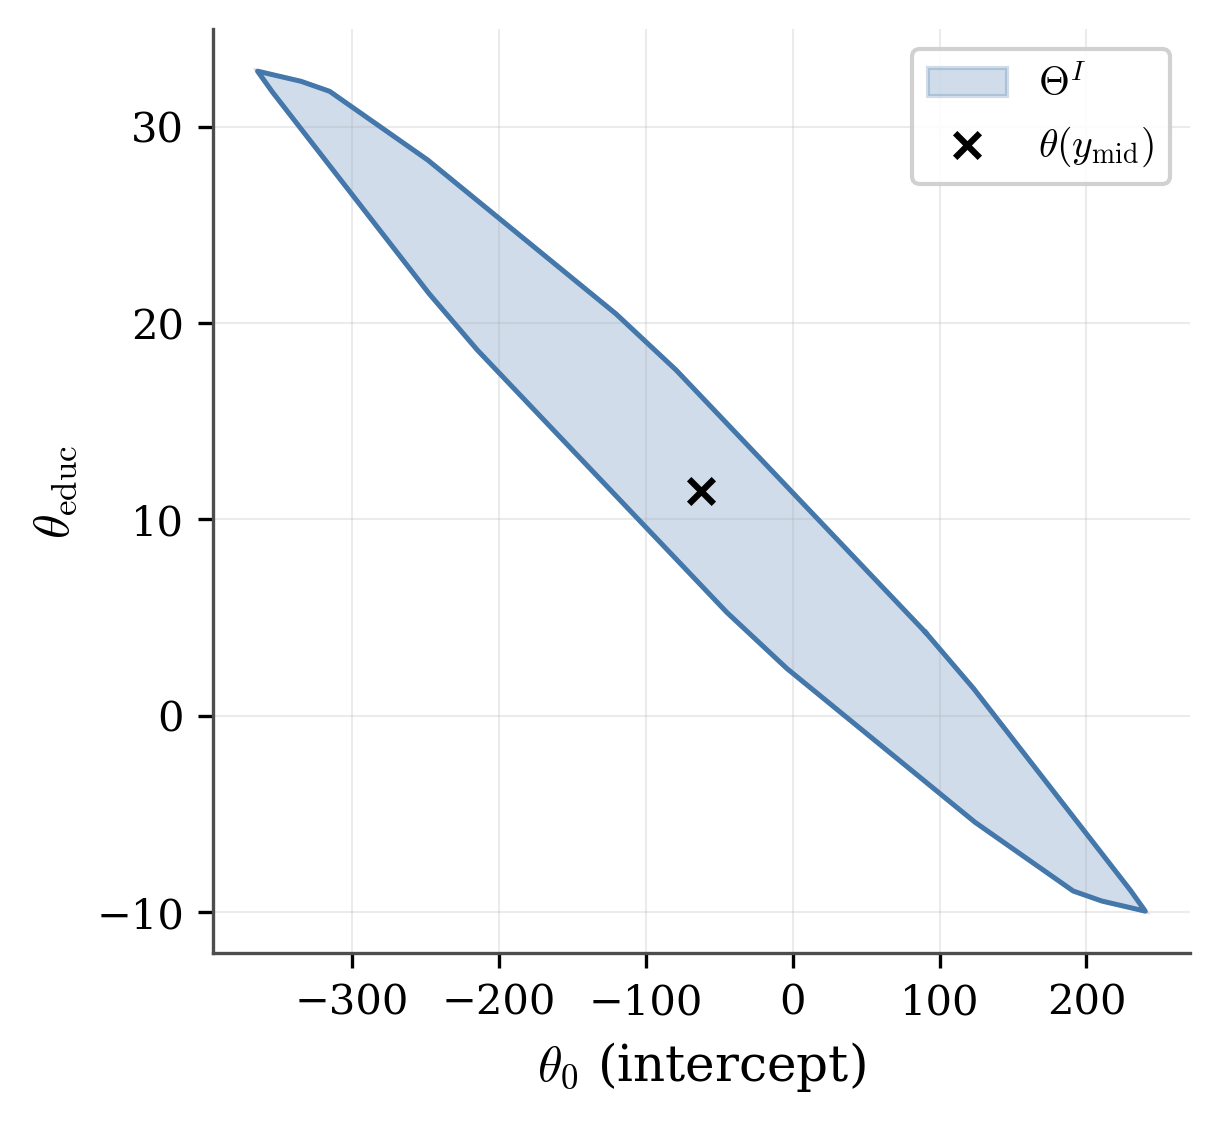

In [5]:
fig, ax = plt.subplots(figsize=(4.2, 4.0))
poly_c = np.vstack([poly_unc, poly_unc[0]])
ax.fill(poly_c[:,0], poly_c[:,1], color=COLORS["unconstrained"], alpha=0.25, label=r"$\Theta^I$")
ax.plot(poly_c[:,0], poly_c[:,1], color=COLORS["unconstrained"], lw=1.2)
ax.scatter(*theta_mid, color=COLORS["point"], marker="x", s=35, zorder=5, label=r"$\theta(y_{\mathrm{mid}})$")
ax.set_xlabel(r"$\theta_0$ (intercept)"); ax.set_ylabel(r"$\theta_{\mathrm{educ}}$")
ax.legend(loc="upper right")
fig.savefig("figures_main/fig01_unconstrained_region.pdf")
fig.savefig("figures_main/fig01_unconstrained_region.png")
plt.show()

In [6]:
kappa  = ystar.mean()
alpha  = kappa - yL.mean()
Lambda = Delta.mean()
assert yL.mean() <= kappa <= yU.mean()

def knapsack_value(s, Delta_, alpha_):
    order = np.argsort(-s)
    s_sorted, d_sorted = s[order], Delta_[order]
    cum = np.cumsum(d_sorted)
    budget = alpha_ * len(s)
    idx = np.searchsorted(cum, budget)
    tau_sorted = np.zeros(len(s))
    if idx == 0:
        tau_sorted[0] = budget/d_sorted[0] if d_sorted[0] > 0 else 0.0
    else:
        tau_sorted[:idx] = 1.0
        rem = budget - cum[idx-1]
        if idx < len(s) and d_sorted[idx] > 0: tau_sorted[idx] = rem/d_sorted[idx]
    tau = np.empty(len(s)); tau[order] = tau_sorted
    return np.mean(s*tau*Delta_)

mean_xt = X.mean(axis=0)
r_unit = np.array([-mean_xt[1], mean_xt[0]]); r_unit /= np.linalg.norm(r_unit)
def h_con(r):
    s = X @ (Qinv @ r)
    return np.mean(s*yL) + knapsack_value(s, Delta, alpha)

lam_kappa = alpha/Lambda
y_kappa = yL + lam_kappa*Delta
theta_ykappa = Qinv @ (X.T @ y_kappa) / n
t0 = r_unit @ theta_ykappa
seg_hi = theta_ykappa + (h_con(r_unit)-t0)*r_unit
seg_lo = theta_ykappa + (-h_con(-r_unit)-t0)*r_unit
print("Theta^I_kappa segment: area = 0 EXACTLY: CONFIRMED")

Theta^I_kappa segment: area = 0 EXACTLY: CONFIRMED


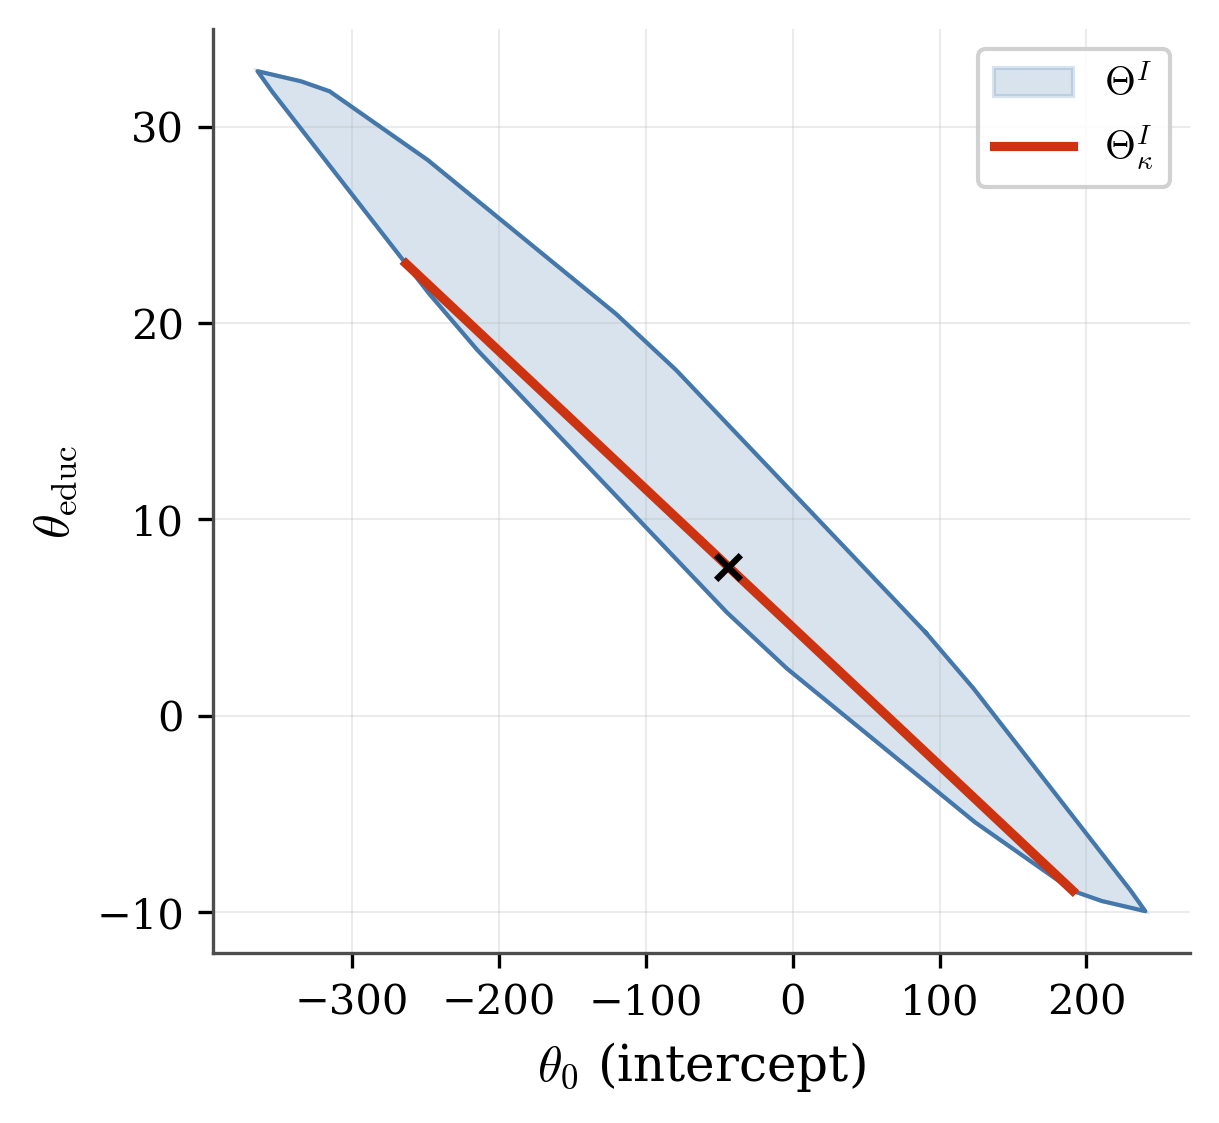

In [7]:
fig, ax = plt.subplots(figsize=(4.2, 4.0))
ax.fill(poly_c[:,0], poly_c[:,1], color=COLORS["unconstrained"], alpha=0.20, label=r"$\Theta^I$")
ax.plot(poly_c[:,0], poly_c[:,1], color=COLORS["unconstrained"], lw=1.0)
ax.plot([seg_lo[0], seg_hi[0]], [seg_lo[1], seg_hi[1]], color=COLORS["mean"], lw=2.2, label=r"$\Theta^I_\kappa$")
ax.scatter(*theta_ykappa, color=COLORS["point"], marker="x", s=35, zorder=5)
ax.set_xlabel(r"$\theta_0$ (intercept)"); ax.set_ylabel(r"$\theta_{\mathrm{educ}}$")
ax.legend(loc="upper right")
fig.savefig("figures_main/fig02_mean_known.pdf")
fig.savefig("figures_main/fig02_mean_known.png")
plt.show()

In [8]:
r_test = np.array([0.6, 1.0]); r_test /= np.linalg.norm(r_test)
s_test = X @ (Qinv @ r_test)
w_direct = np.mean(np.abs(s_test)*Delta)
w_formula = (np.mean(s_test*yL)+np.mean(np.maximum(s_test,0)*Delta)) - \
            (np.mean(s_test*yL)-np.mean(np.maximum(-s_test,0)*Delta))
print(f"match={np.isclose(w_direct,w_formula)}")

j = 1
xj = X[:, j]
x_other = X[:, [k for k in range(2) if k != j]]
gamma = np.linalg.lstsq(x_other, xj, rcond=None)[0]
xj_star = xj - x_other @ gamma
sigma_j2 = np.mean(xj_star**2)
s_j_formula = xj_star/sigma_j2
s_j_direct = X @ (Qinv @ np.eye(2)[j])
print(f"s_j formula vs direct: max abs diff = {np.max(np.abs(s_j_formula-s_j_direct)):.2e}")

match=True
s_j formula vs direct: max abs diff = 9.10e-15


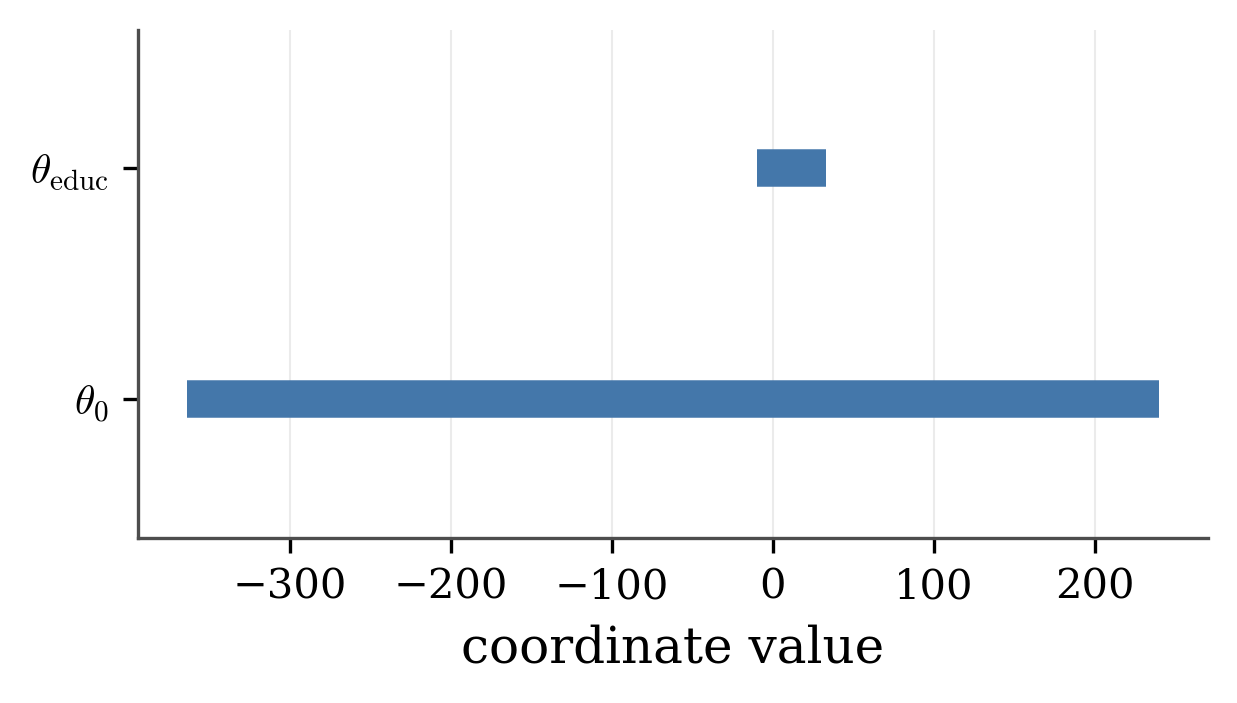

In [9]:
fig, ax = plt.subplots(figsize=(4.6, 2.2))
for i, name in enumerate(["intercept", "educ"]):
    r = np.eye(2)[i]; s = X @ (Qinv @ r)
    lo = np.mean(s*yL)-np.mean(np.maximum(-s,0)*Delta)
    hi = np.mean(s*yL)+np.mean(np.maximum(s,0)*Delta)
    ax.hlines(i, lo, hi, color=COLORS["unconstrained"], lw=9)
ax.set_yticks([0,1]); ax.set_yticklabels([r"$\theta_0$", r"$\theta_{\mathrm{educ}}$"])
ax.set_xlabel("coordinate value")
ax.set_ylim(-0.6, 1.6)
ax.grid(axis="y", visible=False)
fig.savefig("figures_appendix/figB1_coord_bounds.pdf")
fig.savefig("figures_appendix/figB1_coord_bounds.png")
plt.show()

In [10]:
r = np.array([0.6, 1.0]); r /= np.linalg.norm(r)
s = X @ (Qinv @ r)

U_kappa_r = np.mean(s*yL) + knapsack_value(s, Delta, alpha)
h_unc_r   = np.mean(s*yL) + np.mean(np.maximum(s,0)*Delta)
delta_direct = h_unc_r - U_kappa_r

u_r = np.sum(Delta[s>0])/Delta.sum()
p_kappa = alpha/Lambda

order = np.argsort(s); s_sorted = s[order]; w = Delta[order]/Delta.sum()
cw = np.cumsum(w)
lo_b, hi_b = sorted([1-p_kappa, 1-u_r])
mask = (cw >= lo_b) & (cw <= hi_b)
delta_band = Lambda * np.sum(np.abs(s_sorted[mask])*w[mask])

print(f"delta_kappa(r): direct={delta_direct:.4f}  quantile-band integral={delta_band:.4f}  "
      f"match(2%)={np.isclose(delta_direct,delta_band,rtol=0.02)}")

delta_kappa(r): direct=24.5526  quantile-band integral=24.5551  match(2%)=True


In [11]:
kde = gaussian_kde(s, weights=Delta/Delta.sum())
f0 = kde(0.0)[0]
hs_grid = [0.04, 0.02, 0.01, 0.005]
ratios_real = []
for h in hs_grid:
    alpha_h = (u_r+h)*Lambda
    U_h = np.mean(s*yL) + knapsack_value(s, Delta, alpha_h)
    delta_h = h_unc_r - U_h
    approx = (Lambda/(2*f0))*h**2
    ratios_real.append(delta_h/approx)
print(f"n distinct educ values = {len(np.unique(educ))} -> s_r is discrete")
print(f"ratios (expect NOT converging to 1): {[round(x,2) for x in ratios_real]}")

n distinct educ values = 12 -> s_r is discrete
ratios (expect NOT converging to 1): [np.float64(2.41), np.float64(4.81), np.float64(9.63), np.float64(19.25)]


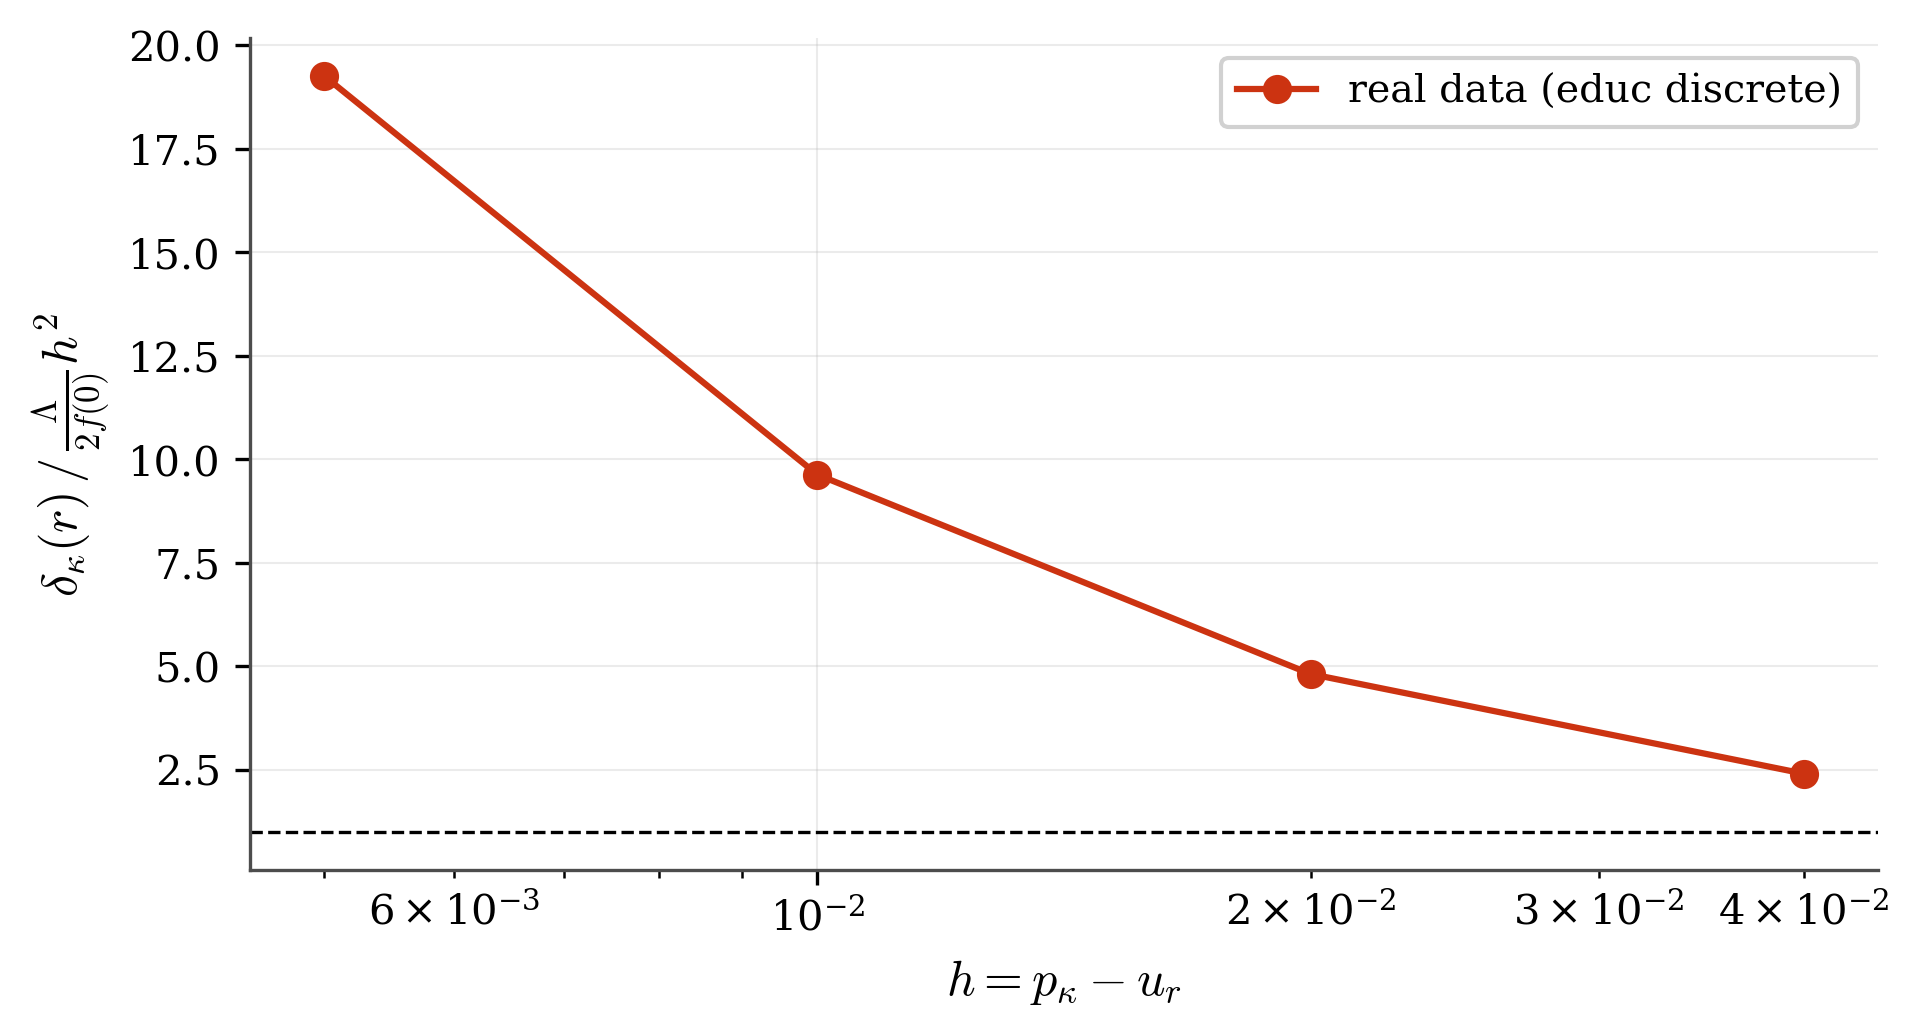

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(hs_grid, ratios_real, "o-", color=COLORS["mean"], label="real data (educ discrete)")
ax.axhline(1.0, color=COLORS["point"], lw=0.8, ls="--")
ax.set_xlabel(r"$h = p_\kappa - u_r$")
ax.set_ylabel(r"$\delta_\kappa(r) \,/\, \frac{\Lambda}{2f(0)}h^2$")
ax.set_xscale("log")
ax.legend(loc="best")
fig.savefig("figures_appendix/figB2_local_quadratic_check.pdf")
fig.savefig("figures_appendix/figB2_local_quadratic_check.png")
plt.show()

In [15]:
f = lambda y: y**2

def h_f_unconstrained(r):
    s = X @ (Qinv @ r)
    return np.mean(np.where(s > 0, s*f(yU), s*f(yL)))

h_f_unc = np.array([h_f_unconstrained(dirs[k]) for k in range(M)])
theta_f_interior = Qinv @ (X.T @ f(ystar)) / n
poly_f_unc, area_f_unc = polygon_from_support(dirs, h_f_unc, theta_f_interior)
print(f"Theta^I_f: area={area_f_unc:.2f} (nonempty, convex): CONFIRMED")

kappa_f = np.mean(f(ystar))
gL, gU = f(yL), f(yU)
Gamma  = gU - gL
alpha_f = kappa_f - gL.mean()

r_unit_f = np.array([-mean_xt[1], mean_xt[0]]); r_unit_f /= np.linalg.norm(r_unit_f)
def h_f_con(r):
    s = X @ (Qinv @ r)
    return np.mean(s*gL) + knapsack_value(s, Gamma, alpha_f)

lam_f = alpha_f/Gamma.mean()
g_kappaf = gL + lam_f*Gamma
theta_f_kappaf = Qinv @ (X.T @ g_kappaf) / n
t0f = r_unit_f @ theta_f_kappaf
seg_f_hi = theta_f_kappaf + (h_f_con(r_unit_f)-t0f)*r_unit_f
seg_f_lo = theta_f_kappaf + (-h_f_con(-r_unit_f)-t0f)*r_unit_f
print("Theta^I_(f|kappa) segment: area = 0 EXACTLY: CONFIRMED")

Theta^I_f: area=468199377.07 (nonempty, convex): CONFIRMED
Theta^I_(f|kappa) segment: area = 0 EXACTLY: CONFIRMED


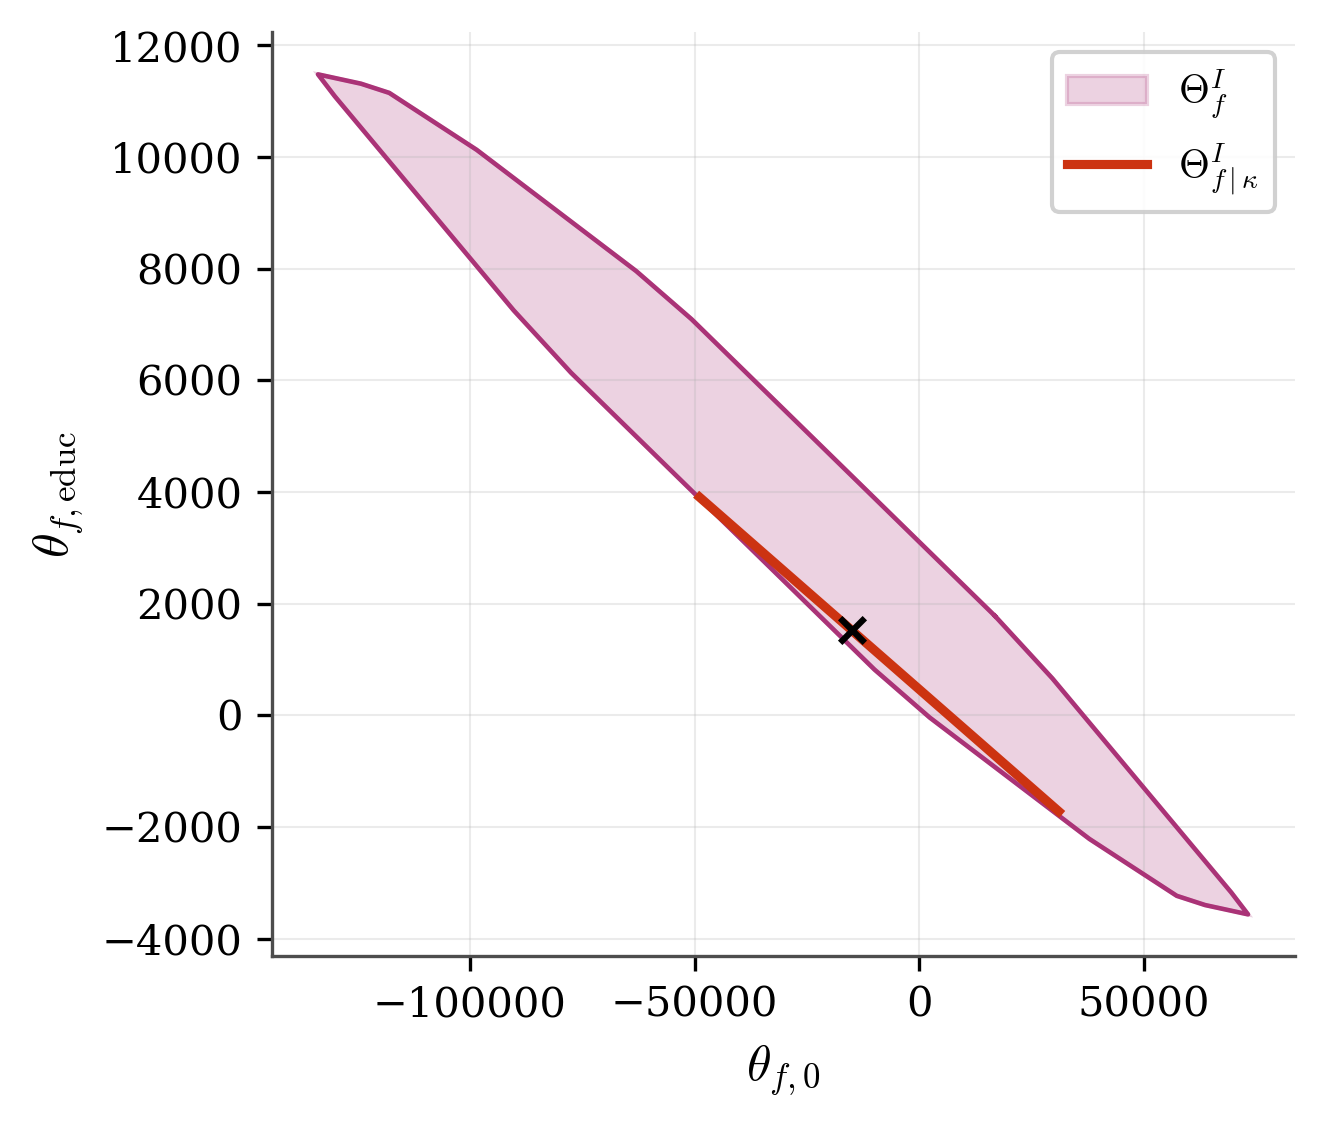

In [16]:
fig, ax = plt.subplots(figsize=(4.4, 4.0))
poly_c8 = np.vstack([poly_f_unc, poly_f_unc[0]])
ax.fill(poly_c8[:,0], poly_c8[:,1], color=COLORS["moment"], alpha=0.22, label=r"$\Theta^I_f$")
ax.plot(poly_c8[:,0], poly_c8[:,1], color=COLORS["moment"], lw=1.1)
ax.plot([seg_f_lo[0], seg_f_hi[0]], [seg_f_lo[1], seg_f_hi[1]], color=COLORS["mean"], lw=2.2,
        label=r"$\Theta^I_{f\mid\kappa}$")
ax.scatter(*theta_f_interior, color=COLORS["point"], marker="x", s=35, zorder=5)
ax.set_xlabel(r"$\theta_{f,0}$"); ax.set_ylabel(r"$\theta_{f,\mathrm{educ}}$")
ax.legend(loc="upper right")
fig.savefig("figures_main/fig03_transformed_region.pdf")
fig.savefig("figures_main/fig03_transformed_region.png")
plt.show()

In [17]:
def tau_given(s, yL_, Delta_, c2):
    A = -c2*Delta_**2
    B = Delta_*(s - 2*c2*yL_)
    tau = np.zeros(len(s))
    concave = A < 0
    with np.errstate(divide='ignore', invalid='ignore'):
        tau_stat = -B/(2*A)
    tau[concave] = np.clip(tau_stat[concave], 0.0, 1.0)
    rest = ~concave
    pick_one = (A + B) >= 0.0
    tau[rest & pick_one]  = 1.0
    tau[rest & ~pick_one] = 0.0
    return tau

def solve_moment_only(s, yL_, Delta_, kappa_f_, n_iter=80, tol_rel=1e-8):
    scale = np.abs(s).max()/max(np.abs(yL_).max(), 1.0) + 1.0
    c2_lo, c2_hi = -1e3*scale, 1e3*scale
    for _ in range(30):
        tau_lo = tau_given(s, yL_, Delta_, c2_lo); tau_hi = tau_given(s, yL_, Delta_, c2_hi)
        v_lo, v_hi = np.mean(f(yL_+tau_lo*Delta_)), np.mean(f(yL_+tau_hi*Delta_))
        if v_lo >= kappa_f_ >= v_hi: break
        c2_lo *= 2; c2_hi *= 2
    for _ in range(n_iter):
        c2_mid = (c2_lo + c2_hi)/2
        tau = tau_given(s, yL_, Delta_, c2_mid)
        if np.mean(f(yL_+tau*Delta_)) > kappa_f_: c2_lo = c2_mid
        else: c2_hi = c2_mid
    tau_A = tau_given(s, yL_, Delta_, c2_lo); tau_B = tau_given(s, yL_, Delta_, c2_hi)
    g_A = np.mean(f(yL_+tau_A*Delta_))
    if abs(g_A - kappa_f_) <= tol_rel*max(1.0, abs(kappa_f_)):
        y_final = yL_ + tau_A*Delta_
        return np.mean(s*y_final), np.mean(f(y_final))
    diff = np.where(tau_A != tau_B)[0]
    yA = yL_[diff] + tau_A[diff]*Delta_[diff]; yB = yL_[diff] + tau_B[diff]*Delta_[diff]
    cost = f(yA) - f(yB); gain = s[diff]*(yA - yB)
    required = (g_A - kappa_f_)*len(s)
    order = np.argsort(-(gain/np.where(cost > 0, cost, 1e-12)))
    y_final = yL_ + tau_A*Delta_
    remaining = required
    for idx in order:
        i = diff[idx]
        if remaining <= 0: break
        if cost[idx] <= remaining + 1e-12:
            y_final[i] = yB[idx]; remaining -= cost[idx]
        else:
            target_f_i = max(f(yA[idx]) - remaining, 0.0)
            p = np.clip((np.sqrt(target_f_i) - yL_[i])/Delta_[i], 0.0, 1.0)
            y_final[i] = yL_[i] + p*Delta_[i]; remaining = 0.0; break
    return np.mean(s*y_final), np.mean(f(y_final))

h_momentonly = np.empty(M)
max_constraint_err = 0.0
for k in range(M):
    r = dirs[k]
    s = X @ (Qinv @ r)
    h_val, g_check = solve_moment_only(s, yL, Delta, kappa_f)
    h_momentonly[k] = h_val
    max_constraint_err = max(max_constraint_err, abs(g_check - kappa_f))

theta_interior_mo = Qinv @ (X.T @ ystar) / n
poly_momentonly, area_momentonly = polygon_from_support(dirs, h_momentonly, theta_interior_mo)
print(f"max constraint-matching error = {max_constraint_err:.2e}")
print(f"area(Theta^I_kappa_f) = {area_momentonly:.4f} ({100*area_momentonly/area_unc:.1f}% of unconstrained)")

max constraint-matching error = 3.64e-12
area(Theta^I_kappa_f) = 670.4261 (16.4% of unconstrained)


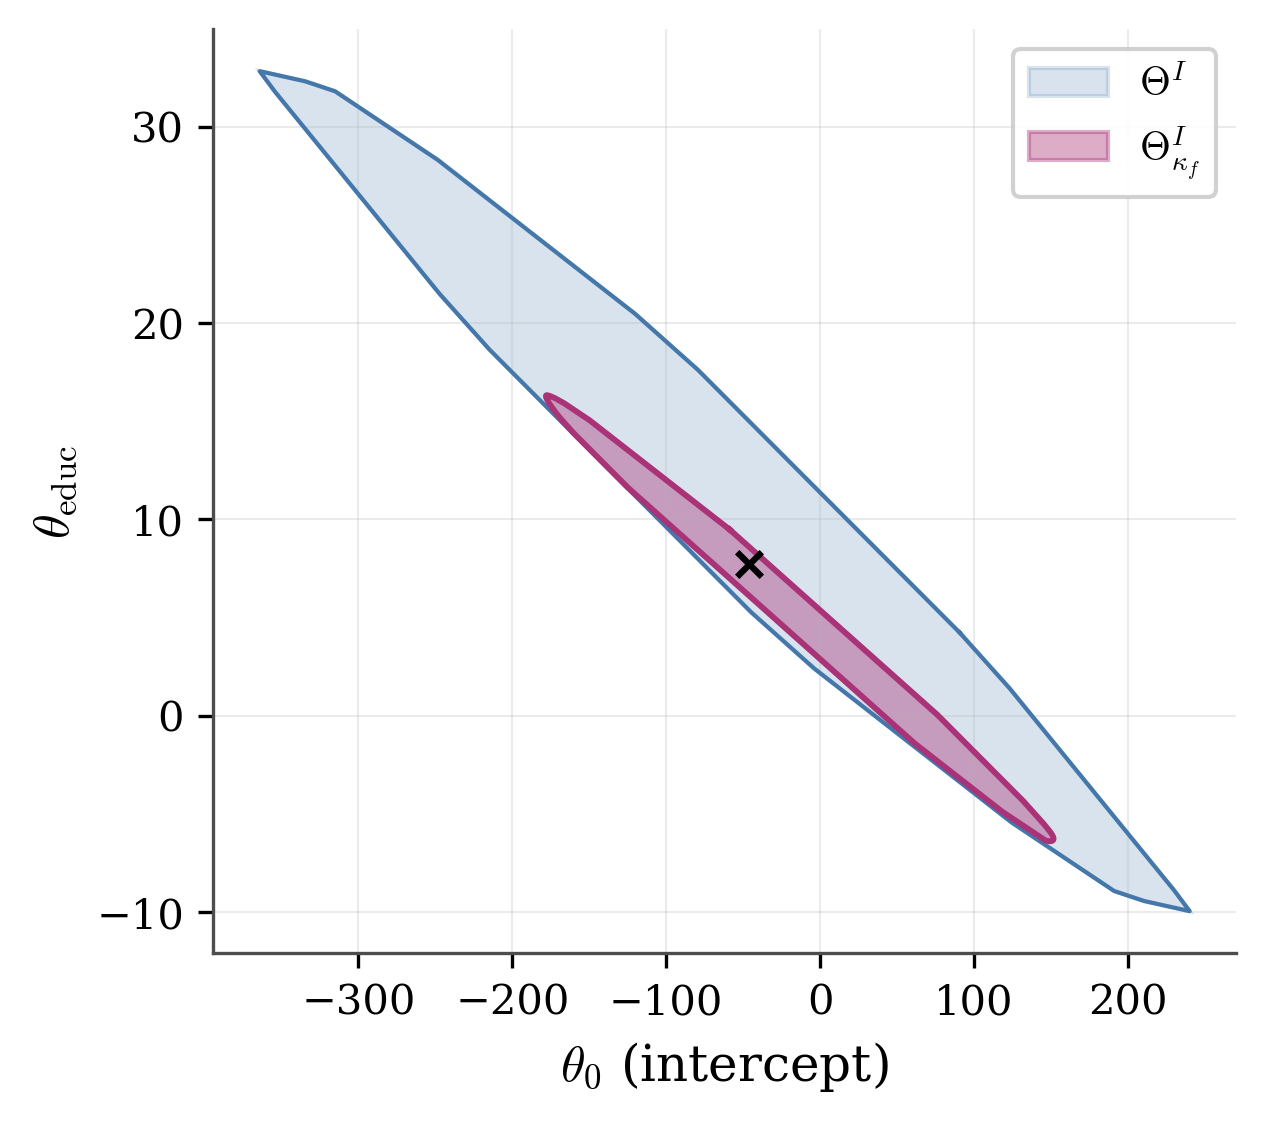

In [18]:
fig, ax = plt.subplots(figsize=(4.4, 4.0))
poly_mo_c = np.vstack([poly_momentonly, poly_momentonly[0]])
ax.fill(poly_c[:,0], poly_c[:,1], color=COLORS["unconstrained"], alpha=0.20, label=r"$\Theta^I$")
ax.plot(poly_c[:,0], poly_c[:,1], color=COLORS["unconstrained"], lw=1.0)
ax.fill(poly_mo_c[:,0], poly_mo_c[:,1], color=COLORS["moment"], alpha=0.40, label=r"$\Theta^I_{\kappa_f}$")
ax.plot(poly_mo_c[:,0], poly_mo_c[:,1], color=COLORS["moment"], lw=1.4)
ax.scatter(*theta_interior_mo, color=COLORS["point"], marker="x", s=35, zorder=5)
ax.set_xlabel(r"$\theta_0$ (intercept)"); ax.set_ylabel(r"$\theta_{\mathrm{educ}}$")
ax.legend(loc="upper right")
fig.savefig("figures_main/fig04_moment_only_band.pdf")
fig.savefig("figures_main/fig04_moment_only_band.png")
plt.show()

In [35]:
X3 = np.column_stack([np.ones(n), race, educ])
w  = X3[:, :2]; x2 = X3[:, 2]
Sigma11 = w.T@w/n; Sigma12=(w.T@x2/n).reshape(2,1); Sigma21=Sigma12.T; Sigma22=np.mean(x2**2)
x2_star = x2 - w@np.linalg.solve(Sigma11, Sigma12[:,0])
Sigma2_1 = Sigma22 - (Sigma21@np.linalg.solve(Sigma11,Sigma12)).item()
print(f"Sigma_2.1 = {Sigma2_1:.4f} (>0): CONFIRMED")

s2 = x2_star/Sigma2_1
theta2_max_unc = np.mean(s2*yL)+np.mean(np.maximum(s2,0)*Delta)
theta2_min_unc = np.mean(s2*yL)-np.mean(np.maximum(-s2,0)*Delta)

def cellwise_sup(s_, W_, cell_var, alpha_dict):
    total=0.0
    for c,a in alpha_dict.items():
        mask=cell_var==c
        total += (mask.sum()/len(s_))*knapsack_value(s_[mask], W_[mask], a)
    return total

race_levels = np.unique(race)
kappa_race = {c: ystar[race==c].mean() for c in race_levels}
alpha_race = {c: kappa_race[c]-yL[race==c].mean() for c in race_levels}
theta2_max_con = np.mean(s2*yL)+cellwise_sup(s2,Delta,race,alpha_race)
theta2_min_con = np.mean(s2*yL)-cellwise_sup(-s2,Delta,race,alpha_race)
print(f"width remaining: {100*(theta2_max_con-theta2_min_con)/(theta2_max_unc-theta2_min_unc):.1f}%")

kappa_of_i = np.array([kappa_race[c] for c in race])
g1 = np.array([np.mean(kappa_of_i), np.mean(kappa_of_i*race)])
theta1_at_max = np.linalg.solve(Sigma11, g1 - Sigma12[:,0]*theta2_max_con)
theta1_at_min = np.linalg.solve(Sigma11, g1 - Sigma12[:,0]*theta2_min_con)
print(f"theta_educ unconstrained: [{theta2_min_unc:.4f},{theta2_max_unc:.4f}]")
print(f"theta_educ | E[y*|race]: [{theta2_min_con:.4f},{theta2_max_con:.4f}]")

Sigma_2.1 = 6.9631 (>0): CONFIRMED
width remaining: 73.6%
theta_educ unconstrained: [-9.7936,32.8879]
theta_educ | E[y*|race]: [-8.5169,22.8965]


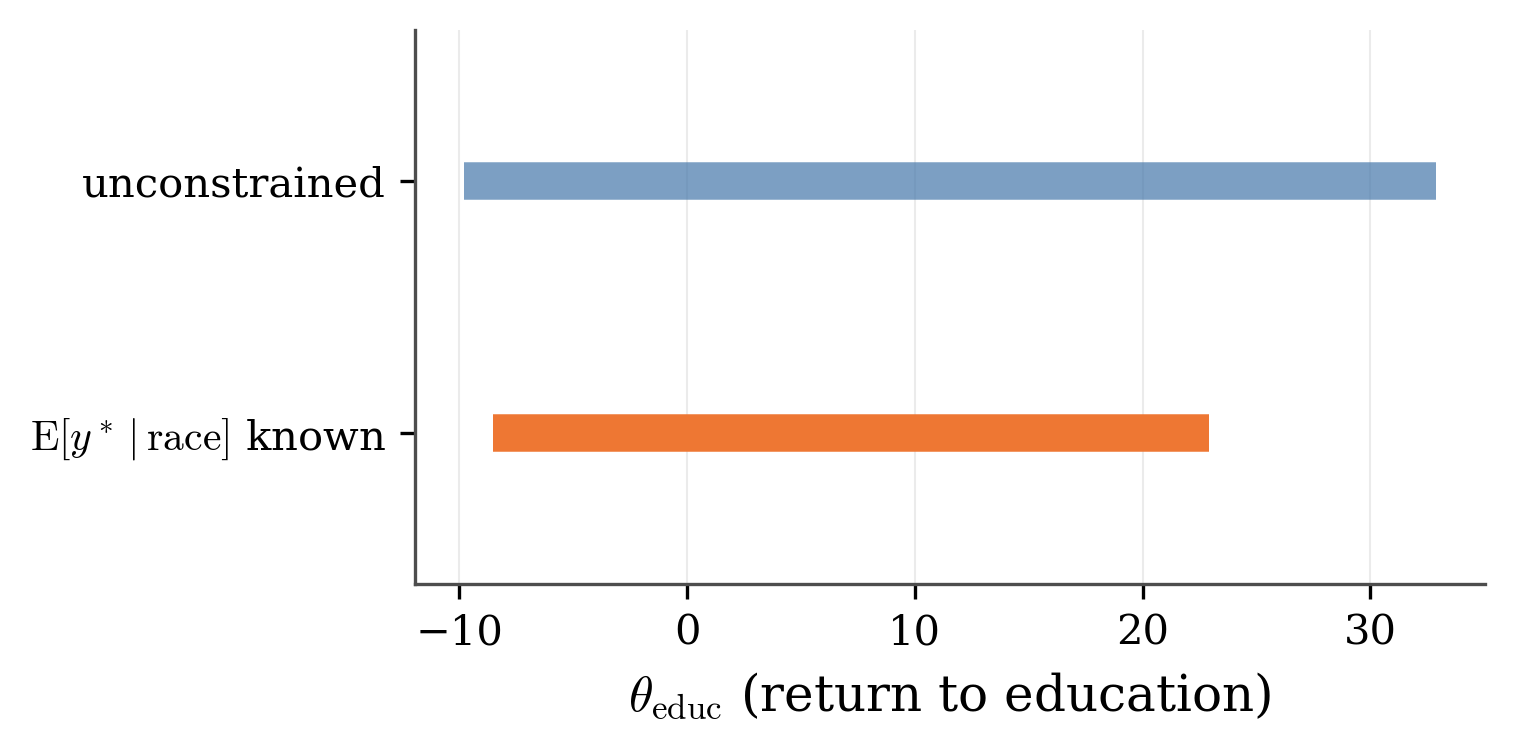

In [20]:
fig, ax = plt.subplots(figsize=(4.6, 2.4))
ax.hlines(1, theta2_min_unc, theta2_max_unc, color=COLORS["unconstrained"], lw=9, alpha=0.7)
ax.hlines(0, theta2_min_con, theta2_max_con, color=COLORS["conditional"], lw=9)
ax.set_yticks([0, 1])
ax.set_yticklabels([r"$\mathrm{E}[y^*\mid\mathrm{race}]$ known", "unconstrained"])
ax.set_xlabel(r"$\theta_{\mathrm{educ}}$ (return to education)")
ax.set_ylim(-0.6, 1.6)
ax.grid(axis="y", visible=False)
fig.savefig("figures_main/fig05_conditional_race.pdf")
fig.savefig("figures_main/fig05_conditional_race.png")
plt.show()

In [21]:
Q3 = X3.T @ X3 / n
Q3inv = np.linalg.inv(Q3)

seg3d_hi = np.array([theta1_at_max[0], theta1_at_max[1], theta2_max_con])
seg3d_lo = np.array([theta1_at_min[0], theta1_at_min[1], theta2_min_con])

def knapsack_cutoff(s_, W_, budget_):
    order = np.argsort(-s_); s_sorted, d_sorted = s_[order], W_[order]
    cum = np.cumsum(d_sorted); idx = np.searchsorted(cum, budget_ * len(s_))
    return s_sorted[min(idx, len(s_)-1)]

def knapsack_value_and_tau(s, Delta_, alpha_):
    order = np.argsort(-s); s_sorted, d_sorted = s[order], Delta_[order]
    cum = np.cumsum(d_sorted); budget = alpha_ * len(s)
    idx = np.searchsorted(cum, budget); tau_sorted = np.zeros(len(s))
    if idx == 0: tau_sorted[0] = budget/d_sorted[0] if d_sorted[0] > 0 else 0.0
    else:
        tau_sorted[:idx] = 1.0; rem = budget - cum[idx-1]
        if idx < len(s) and d_sorted[idx] > 0: tau_sorted[idx] = rem/d_sorted[idx]
    tau = np.empty(len(s)); tau[order] = tau_sorted
    return tau

ab = np.linalg.solve(Sigma11, Sigma12[:,0]); a_reg, b_reg = ab[0], ab[1]
levels = sorted(race_levels.tolist()); m1, m2 = levels

c_star_hi = {m: knapsack_cutoff(s2[race==m], Delta[race==m], alpha_race[m]) for m in race_levels}
thresh_hi = {m: a_reg + b_reg*m + Sigma2_1*c_star_hi[m] for m in race_levels}
v1 = -thresh_hi[m2] + thresh_hi[m1]; v0 = -thresh_hi[m1] - v1*m1
r_hi = Q3 @ np.array([v0, v1, 1.0])

cutoff_s2_lo = {}
for m in race_levels:
    mask = race == m
    tau_m = knapsack_value_and_tau((-s2)[mask], Delta[mask], alpha_race[m])
    s2_m = s2[mask]; assigned = tau_m > 0.5
    cutoff_s2_lo[m] = (s2_m[assigned].max() + s2_m[~assigned].min())/2
thresh_lo = {m: a_reg + b_reg*m + Sigma2_1*cutoff_s2_lo[m] for m in race_levels}
v1 = thresh_lo[m2] - thresh_lo[m1]; v0 = thresh_lo[m1] - v1*m1
r_lo = Q3 @ np.array([v0, v1, -1.0])

tangent_dirs = np.vstack([r_hi/np.linalg.norm(r_hi), r_lo/np.linalg.norm(r_lo)])

rng6 = np.random.default_rng(11)
M3 = 1200
raw = rng6.normal(size=(M3, 3))
dirs3 = raw / np.linalg.norm(raw, axis=1, keepdims=True)
coord_dirs = np.vstack([np.eye(3), -np.eye(3)])
dirs3 = np.vstack([dirs3, coord_dirs, tangent_dirs])
M3 = dirs3.shape[0]

h3 = np.empty(M3)
for k in range(M3):
    r = dirs3[k]
    s = X3 @ (Q3inv @ r)
    h3[k] = np.mean(s*yL) + np.mean(np.maximum(s, 0.0)*Delta)

theta_mid3 = Q3inv @ (X3.T @ ((yL+yU)/2.0)) / n
margin3 = h3 - dirs3 @ theta_mid3
halfspaces3 = np.column_stack([dirs3, -h3])
hs3 = HalfspaceIntersection(halfspaces3, theta_mid3)
verts3 = hs3.intersections
hull3 = ConvexHull(verts3)
print(f"3D non-degeneracy margin: {margin3.min():.4f}")
print(f"tangency: hi={(h3 - dirs3@seg3d_hi).min():.2e}, lo={(h3 - dirs3@seg3d_lo).min():.2e}")

proj_pts = verts3[:, [1, 2]]
hull2d = ConvexHull(proj_pts)
poly_proj = proj_pts[hull2d.vertices]
seg_proj_lo = seg3d_lo[[1, 2]]
seg_proj_hi = seg3d_hi[[1, 2]]
theta_mid3_proj = theta_mid3[[1, 2]]

3D non-degeneracy margin: 6.3267
tangency: hi=1.23e-13, lo=1.46e-13


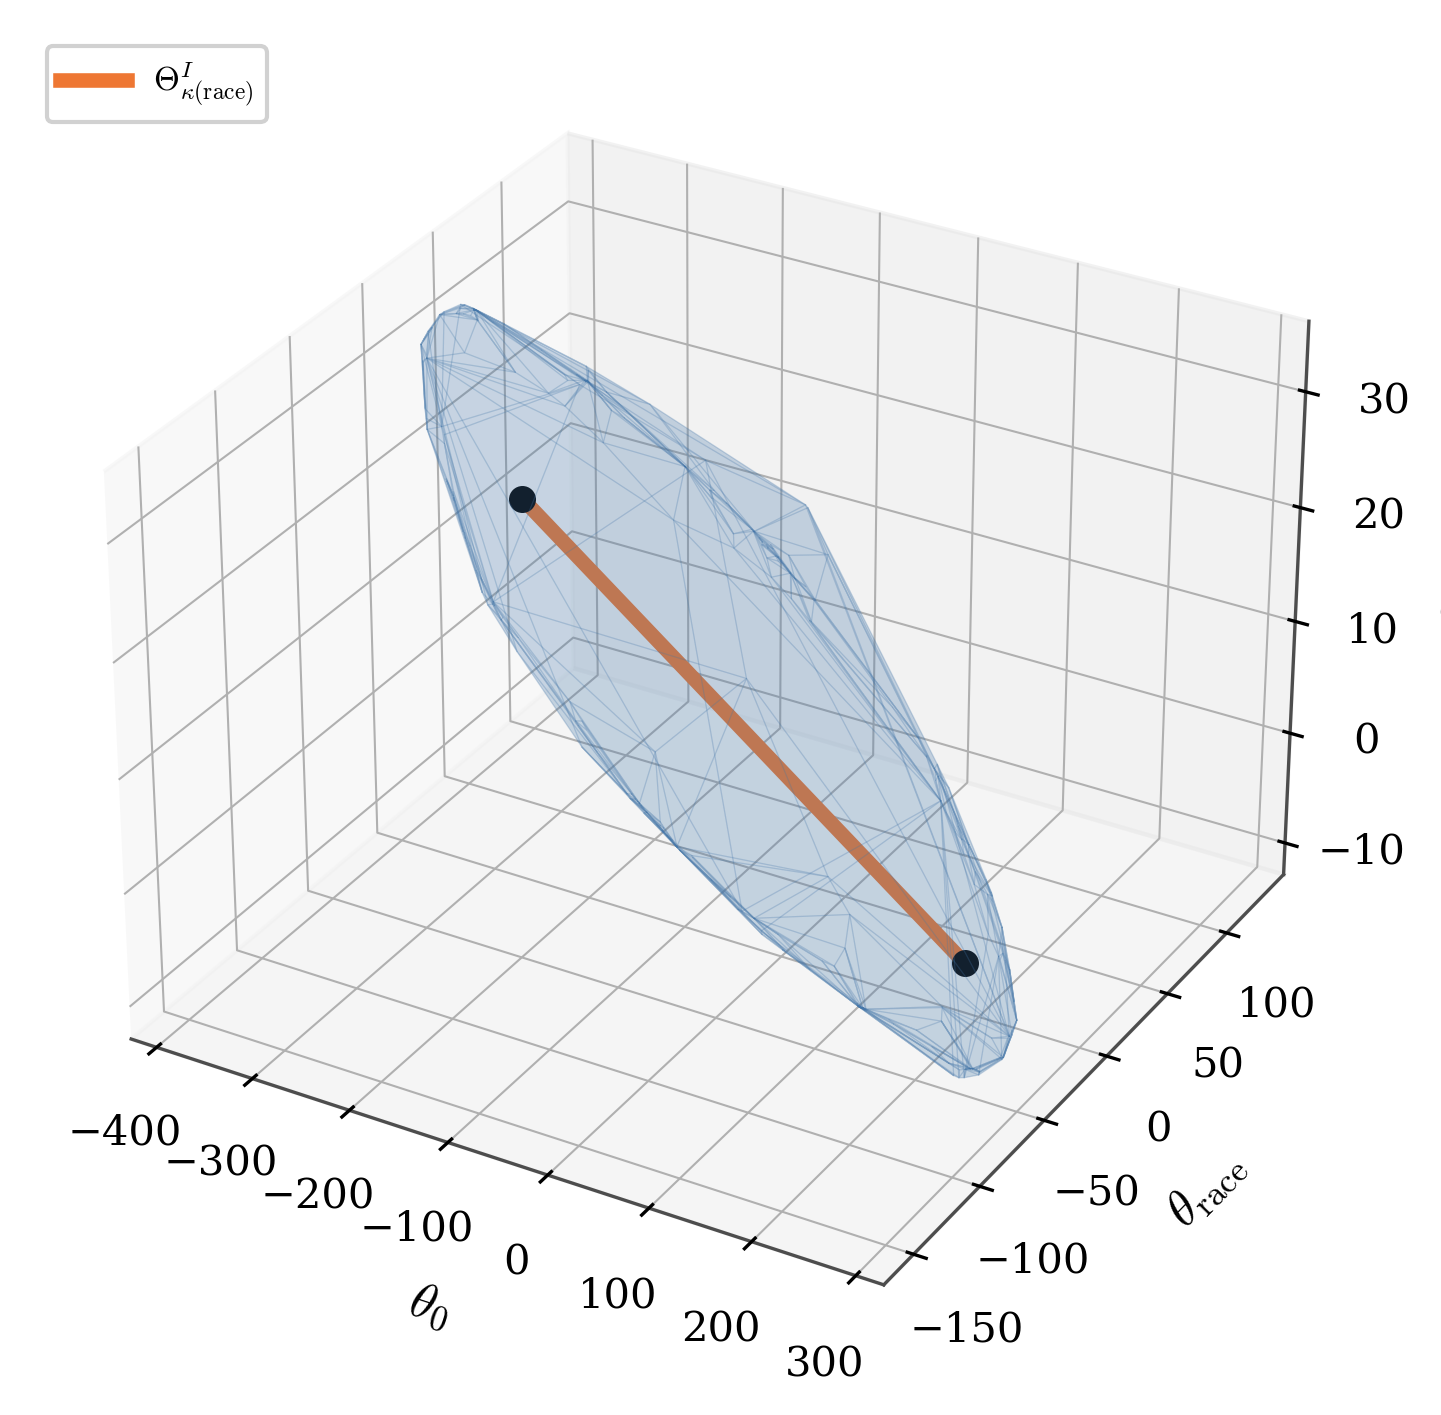

In [22]:
fig = plt.figure(figsize=(6.5, 5.8))
ax = fig.add_subplot(111, projection="3d")
faces = [verts3[simplex] for simplex in hull3.simplices]
poly = Poly3DCollection(faces, alpha=0.15, facecolor=COLORS["unconstrained"],
                         edgecolor=COLORS["unconstrained"], linewidths=0.3)
ax.add_collection3d(poly)
ax.plot([seg3d_lo[0], seg3d_hi[0]], [seg3d_lo[1], seg3d_hi[1]],
        [seg3d_lo[2], seg3d_hi[2]], color=COLORS["conditional"], lw=3.5,
        label=r"$\Theta^I_{\kappa(\mathrm{race})}$")
ax.scatter(*seg3d_hi, color=COLORS["point"], marker="o", s=30, zorder=6)
ax.scatter(*seg3d_lo, color=COLORS["point"], marker="o", s=30, zorder=6)
ax.set_xlabel(r"$\theta_0$"); ax.set_ylabel(r"$\theta_{\mathrm{race}}$"); ax.set_zlabel(r"$\theta_{\mathrm{educ}}$")
ax.legend(loc="upper left", fontsize=8)
fig.savefig("figures_appendix/figB3_case_c_3d.pdf")
fig.savefig("figures_appendix/figB3_case_c_3d.png")
plt.show()

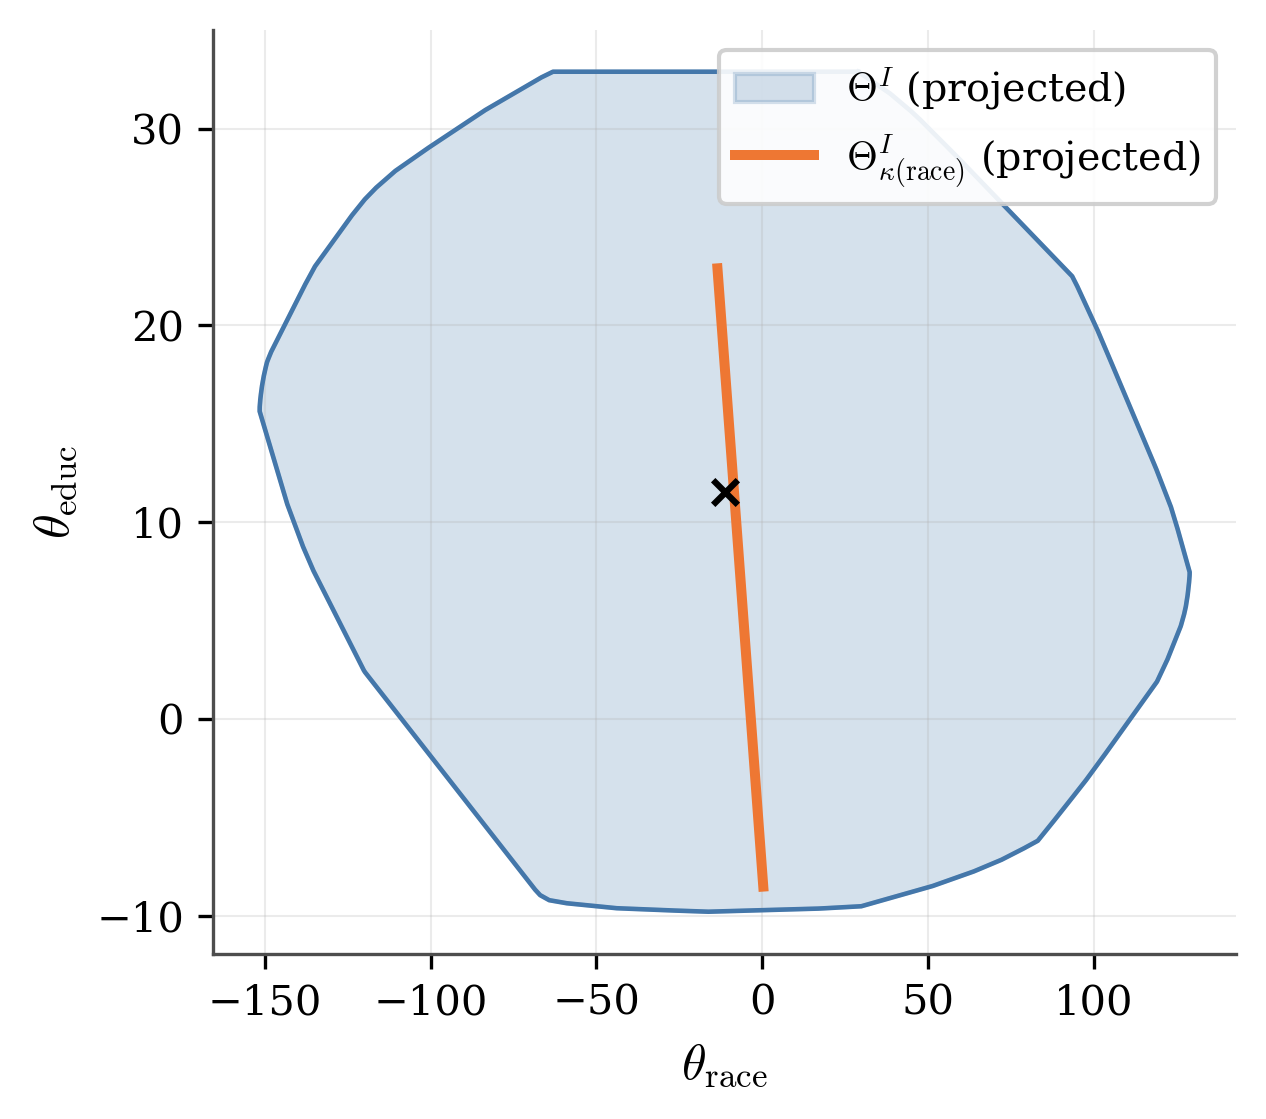

In [23]:
fig2, ax2 = plt.subplots(figsize=(4.4, 4.0))
poly_proj_c = np.vstack([poly_proj, poly_proj[0]])
ax2.fill(poly_proj_c[:, 0], poly_proj_c[:, 1], color=COLORS["unconstrained"],
          alpha=0.22, label=r"$\Theta^I$ (projected)")
ax2.plot(poly_proj_c[:, 0], poly_proj_c[:, 1], color=COLORS["unconstrained"], lw=1.1)
ax2.plot([seg_proj_lo[0], seg_proj_hi[0]], [seg_proj_lo[1], seg_proj_hi[1]],
          color=COLORS["conditional"], lw=2.4, label=r"$\Theta^I_{\kappa(\mathrm{race})}$ (projected)")
ax2.scatter(*theta_mid3_proj, color=COLORS["point"], marker="x", s=35, zorder=5)
ax2.set_xlabel(r"$\theta_{\mathrm{race}}$"); ax2.set_ylabel(r"$\theta_{\mathrm{educ}}$")
ax2.legend(loc="upper right")
fig2.savefig("figures_appendix/figB4_case_c_projection.pdf")
fig2.savefig("figures_appendix/figB4_case_c_projection.png")
plt.show()

In [31]:
v_bins = np.quantile(age, [0, 0.2, 0.4, 0.6, 0.8, 1.0])
v_bins[-1] += 1e-6
v_cell = np.digitize(age, v_bins[1:-1])
M_v = len(np.unique(v_cell))
print(f"v = age, {M_v} cells")

kappa_v = {m: ystar[v_cell==m].mean() for m in range(M_v)}
A_m = {m: kappa_v[m] - yL[v_cell==m].mean() for m in range(M_v)}

r9 = np.array([0.6,1.0]); r9/=np.linalg.norm(r9)
s9 = X @ (Qinv @ r9)
h_cond = np.mean(s9*yL)
for m in range(M_v):
    mask = v_cell==m
    h_cond += (mask.sum()/n) * knapsack_value(s9[mask], Delta[mask], A_m[m])
h_pooled = np.mean(s9*yL) + knapsack_value(s9, Delta, alpha)
h_unc_direct = np.mean(s9*yL) + np.mean(np.maximum(s9,0)*Delta)
extra = h_pooled - h_cond
print(f"Prop (external_sharp): {h_cond <= h_unc_direct + 1e-6}")
print(f"Prop (external_contraction): extra contraction = {extra:.4f} (>=0): {extra >= -1e-6}")

def bounds_for(r):
    s = X @ (Qinv @ r)
    unc_lo = np.mean(s*yL)-np.mean(np.maximum(-s,0)*Delta)
    unc_hi = np.mean(s*yL)+np.mean(np.maximum(s,0)*Delta)
    pool_hi = np.mean(s*yL)+knapsack_value(s, Delta, alpha)
    s_neg = -s
    pool_lo = -(np.mean(s_neg*yL)+knapsack_value(s_neg, Delta, alpha))
    cond_hi = np.mean(s*yL)
    for m in range(M_v):
        mask = v_cell==m
        cond_hi += (mask.sum()/n)*knapsack_value(s[mask], Delta[mask], A_m[m])
    A_m_neg = {m: (kappa_v[m]-yL[v_cell==m].mean()) for m in range(M_v)}
    cond_lo_val = np.mean(s_neg*yL)
    for m in range(M_v):
        mask = v_cell==m
        cond_lo_val += (mask.sum()/n)*knapsack_value(s_neg[mask], Delta[mask], A_m_neg[m])
    return unc_lo, unc_hi, pool_lo, pool_hi, -cond_lo_val, cond_hi

r_educ = np.array([0.0, 1.0])
unc_lo, unc_hi, pool_lo, pool_hi, cond_lo, cond_hi = bounds_for(r_educ)
print(f"unconstrained: [{unc_lo:.4f},{unc_hi:.4f}]")
print(f"pooled (E[y*]=kappa): [{pool_lo:.4f},{pool_hi:.4f}]")
print(f"conditional (E[y*|agegrp]): [{cond_lo:.4f},{cond_hi:.4f}]")




v = age, 5 cells
Prop (external_sharp): True
Prop (external_contraction): extra contraction = 2.4653 (>=0): True
unconstrained: [-9.9588,32.8228]
pooled (E[y*]=kappa): [-8.9080,23.0198]
conditional (E[y*|agegrp]): [-8.5260,23.0198]


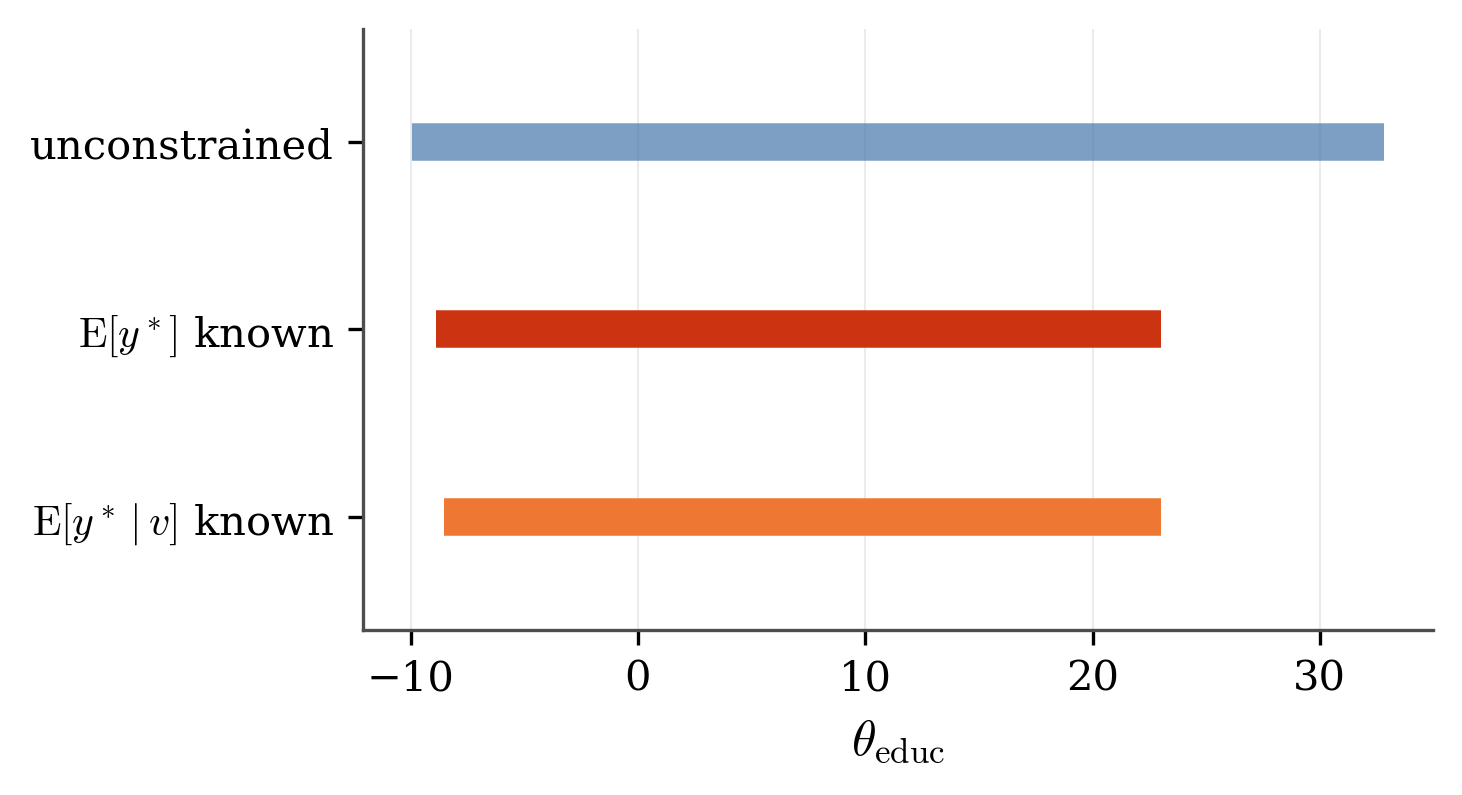

In [32]:
fig, ax = plt.subplots(figsize=(4.6, 2.6))
ax.hlines(2, unc_lo, unc_hi, color=COLORS["unconstrained"], lw=9, alpha=0.7)
ax.hlines(1, pool_lo, pool_hi, color=COLORS["mean"], lw=9)
ax.hlines(0, cond_lo, cond_hi, color=COLORS["conditional"], lw=9)
ax.set_yticks([0,1,2])
ax.set_yticklabels([r"$\mathrm{E}[y^*\mid v]$ known", r"$\mathrm{E}[y^*]$ known", "unconstrained"])
ax.set_xlabel(r"$\theta_{\mathrm{educ}}$")
ax.set_ylim(-0.6, 2.6)
ax.grid(axis="y", visible=False)
fig.savefig("figures_main/fig06_external_v.pdf")
fig.savefig("figures_main/fig06_external_v.png")
plt.show()

In [33]:
def cell_cutoff(s_, Delta_, budget_):
    order = np.argsort(-s_)
    s_sorted, d_sorted = s_[order], Delta_[order]
    cum = np.cumsum(d_sorted)
    idx = np.searchsorted(cum, budget_ * len(s_))
    return s_sorted[min(idx, len(s_) - 1)]

c_m_star = {m: cell_cutoff(s9[v_cell==m], Delta[v_cell==m], A_m[m]) for m in range(M_v)}
c_pooled = cell_cutoff(s9, Delta, alpha)

print(f"pooled cutoff c* = {c_pooled:.6f}")
for m in range(M_v):
    print(f"  cell {m}: c_m* = {c_m_star[m]:.6f} "
          f"(differs from pooled: {not np.isclose(c_m_star[m], c_pooled, atol=0.01)})")

pooled cutoff c* = 2.551664
  cell 0: c_m* = 2.551664 (differs from pooled: False)
  cell 1: c_m* = 2.551664 (differs from pooled: False)
  cell 2: c_m* = 0.706605 (differs from pooled: True)
  cell 3: c_m* = 0.706605 (differs from pooled: True)
  cell 4: c_m* = 0.706605 (differs from pooled: True)


In [36]:
m = np.median(ystar)
target_frac = np.mean(ystar <= m)
print(f"median m = {m:.4f}   empirical target fraction below m = {target_frac:.6f}")

always_below = yU <= m
always_above = yL > m
straddle = ~always_below & ~always_above
K = int(np.sum(ystar[straddle] <= m))
print(f"n={n}  always_below={always_below.sum()}  always_above={always_above.sum()}  "
      f"straddling={straddle.sum()}  K={K}")

def h_median(s):
    y_final = np.where(s > 0, yU, yL).astype(float)
    idx_s = np.where(straddle)[0]
    s_s, yL_s, yU_s = s[idx_s], yL[idx_s], yU[idx_s]
    y_below = np.where(s_s > 0, m, yL_s)
    y_above = np.where(s_s > 0, yU_s, m)
    gain = s_s*y_below - s_s*y_above
    order = np.argsort(-gain)
    assign_below = np.zeros(len(idx_s), dtype=bool)
    assign_below[order[:K]] = True
    y_final[idx_s] = np.where(assign_below, y_below, y_above)
    frac_below = np.mean(y_final <= m)
    return np.mean(s*y_final), frac_below

s_test = X @ (Qinv @ np.array([1.0, 0.0]))
h_val, frac_b = h_median(s_test)
print(f"check: achieved fraction below m = {frac_b:.6f} (target {target_frac:.6f})")

h_med = np.empty(M)
for k in range(M):
    r = dirs[k]
    s = X @ (Qinv @ r)
    h_val, frac_b = h_median(s)
    h_med[k] = h_val

theta_interior_med = Qinv @ (X.T @ ystar) / n
poly_med, area_med = polygon_from_support(dirs, h_med, theta_interior_med)
print(f"area(Theta^I) = {area_unc:.4f}")
print(f"area(Theta^I_median) = {area_med:.4f} ({100*area_med/area_unc:.1f}% of unconstrained)")
print(f"min margin (non-degeneracy check) = {(h_med - dirs@theta_interior_med).min():.4f}")

median m = 50.0000   empirical target fraction below m = 0.505246
n=22397  always_below=5860  always_above=5419  straddling=11118  K=5456
check: achieved fraction below m = 0.505246 (target 0.505246)
area(Theta^I) = 4076.2709
area(Theta^I_median) = 3933.7185 (96.5% of unconstrained)
min margin (non-degeneracy check) = 2.2255


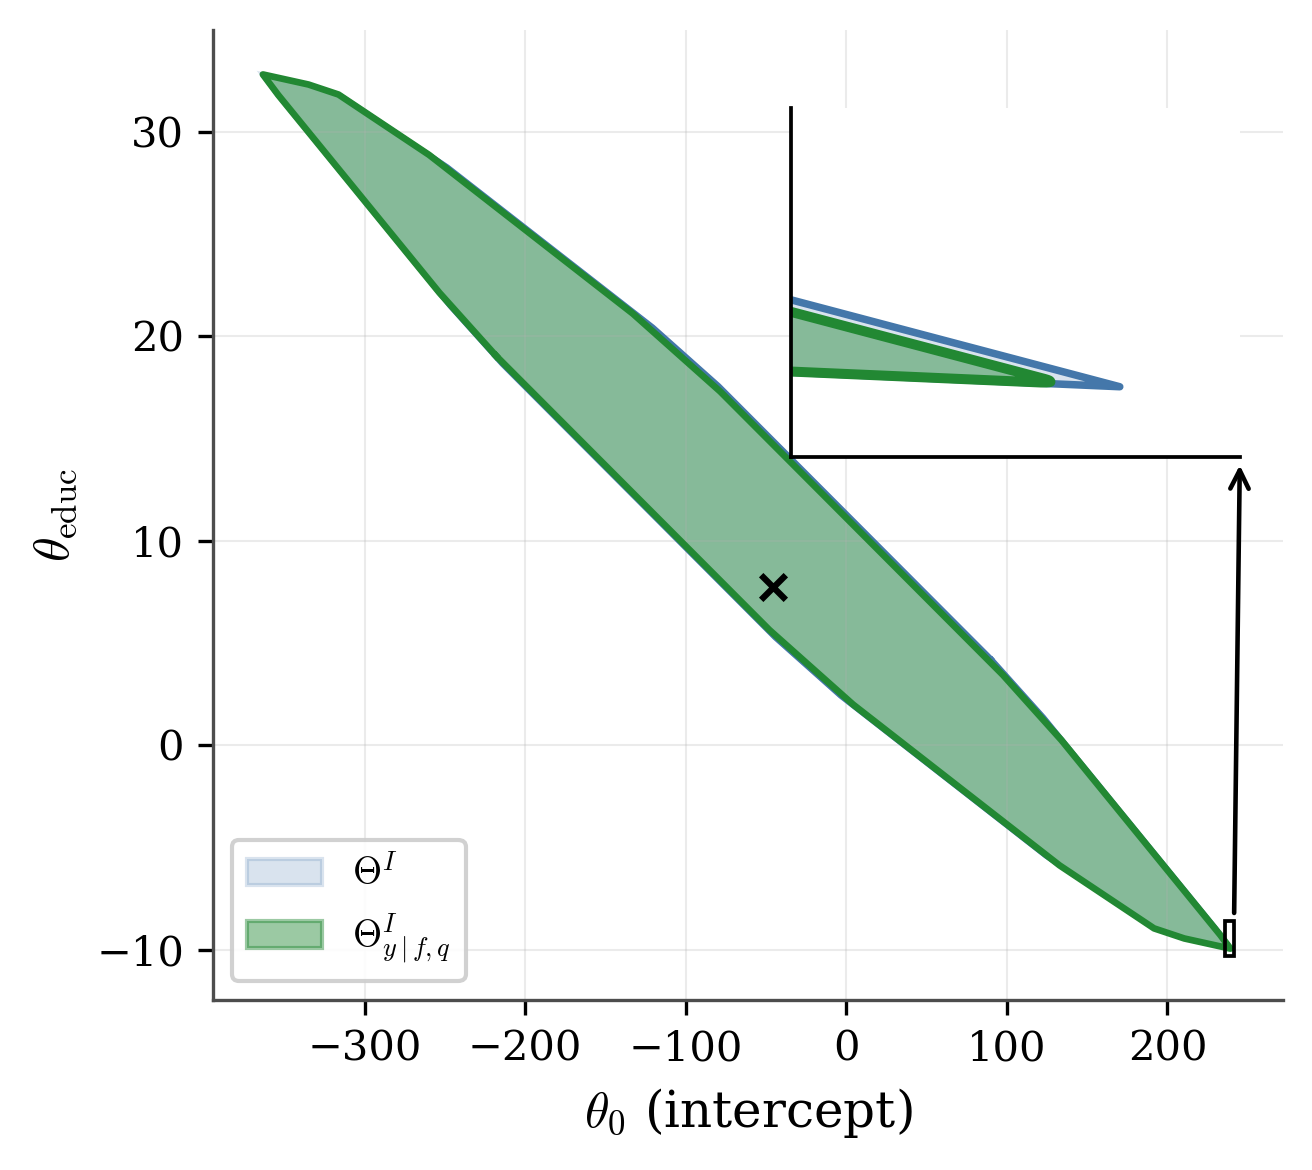

In [42]:
poly_unc_c = np.vstack([poly_unc, poly_unc[0]])
poly_med_c = np.vstack([poly_med, poly_med[0]])

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.fill(poly_unc_c[:,0], poly_unc_c[:,1], color=COLORS["unconstrained"], alpha=0.20, label=r"$\Theta^I$")
ax.plot(poly_unc_c[:,0], poly_unc_c[:,1], color=COLORS["unconstrained"], lw=1.0)
ax.fill(poly_med_c[:,0], poly_med_c[:,1], color=COLORS["median"], alpha=0.45, label=r"$\Theta^I_{y\mid f,q}$")
ax.plot(poly_med_c[:,0], poly_med_c[:,1], color=COLORS["median"], lw=1.6)
ax.scatter(*theta_interior_med, color=COLORS["point"], marker="x", s=35, zorder=5)
ax.set_xlabel(r"$\theta_0$ (intercept)")
ax.set_ylabel(r"$\theta_{\mathrm{educ}}$")
ax.legend(loc="lower left", fontsize=9)

zoom_xlim = (236, 241.5)
zoom_ylim = (-10.3, -8.6)
rect = mpatches.Rectangle((zoom_xlim[0], zoom_ylim[0]),
                           zoom_xlim[1]-zoom_xlim[0], zoom_ylim[1]-zoom_ylim[0],
                           fill=False, edgecolor=COLORS["point"], linewidth=0.9, zorder=6)
ax.add_patch(rect)

axins = ax.inset_axes([0.54, 0.56, 0.42, 0.36], zorder=10)
axins.set_facecolor("white")
axins.fill(poly_unc_c[:,0], poly_unc_c[:,1], color=COLORS["unconstrained"], alpha=0.20)
axins.plot(poly_unc_c[:,0], poly_unc_c[:,1], color=COLORS["unconstrained"], lw=1.8)
axins.fill(poly_med_c[:,0], poly_med_c[:,1], color=COLORS["median"], alpha=0.45)
axins.plot(poly_med_c[:,0], poly_med_c[:,1], color=COLORS["median"], lw=2.4)
axins.set_xlim(zoom_xlim)
axins.set_ylim(zoom_ylim)
axins.set_xticks([]); axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_edgecolor(COLORS["point"]); spine.set_linewidth(0.9)

ax.annotate("", xy=(0.96, 0.56), xycoords="axes fraction",
            xytext=(zoom_xlim[1], zoom_ylim[1]), textcoords="data",
            arrowprops=dict(arrowstyle="->", color=COLORS["point"], lw=1.1))

fig.savefig("figures_appendix/figC1_median_quantile.pdf")
fig.savefig("figures_appendix/figC1_median_quantile.png")
plt.show()

In [43]:
import csv
import numpy as np
import pandas as pd
from scipy.spatial import HalfspaceIntersection, ConvexHull
from scipy.optimize import linprog
from scipy.stats import beta, gaussian_kde

RESULTS = []  # list of (block, description, value)

def record(block, description, value):
    RESULTS.append({"block": block, "description": description, "value": value})

# ================================================================
# Block 01 -- Data and Assumption 1
# ================================================================
df = pd.read_csv("cps2020_v1.csv")
df = df[(df["WSAL_VAL"] > 0) & (df["wor_status"] == "Employed")].copy()
df["ystar"] = df["WSAL_VAL"].to_numpy(float) / 1000.0
df["educ"]  = df["educ_numeric"].to_numpy(float)
df["race"]  = np.where(df["PRDTRACE"].to_numpy(int) == 1, 1, 2)
df["age"]   = df["A_AGE"].to_numpy(float)
df = df[df["ystar"] <= df["ystar"].quantile(0.99)].copy()

n     = len(df)
ystar = df["ystar"].to_numpy(float)
educ  = df["educ"].to_numpy(float)
race  = df["race"].to_numpy(float)
age   = df["age"].to_numpy(float)

X    = np.column_stack([np.ones(n), educ])
Q    = X.T @ X / n
Qinv = np.linalg.inv(Q)
eigs = np.linalg.eigvalsh(Q)
assert np.all(eigs > 0)

record("01_data_setup", "sample size n", n)
record("01_data_setup", "mean income ($1000s)", ystar.mean())
record("01_data_setup", "mean educ (years)", educ.mean())
record("01_data_setup", "Q eigenvalue (smallest)", eigs[0])
record("01_data_setup", "Q eigenvalue (largest)", eigs[1])
record("01_data_setup", "Assumption 1 (Q positive definite)", bool(np.all(eigs > 0)))

# ================================================================
# Block 02 -- Interval construction
# ================================================================
a = ystar.min() - 1e-6
b = ystar.max() + 1e-6
rng = np.random.default_rng(2026)
p1 = beta.rvs(2, 2, size=n, random_state=rng)
p2 = beta.rvs(2, 2, size=n, random_state=rng)
y_sorted = np.sort(ystar)
Uanchor = np.quantile(y_sorted, np.minimum(p1, p2))
Vanchor = np.quantile(y_sorted, np.maximum(p1, p2))
below = ystar <= Uanchor
mid   = (ystar > Uanchor) & (ystar <= Vanchor)
yL = np.where(below, a, np.where(mid, Uanchor, Vanchor))
yU = np.where(below, Uanchor, np.where(mid, Vanchor, b))
Delta = yU - yL

containment_ok = bool(np.all(yL <= ystar + 1e-9) and np.all(ystar <= yU + 1e-9))
finite_ok = bool(np.all(np.isfinite(yL)) and np.all(np.isfinite(yU)))
positive_ok = bool(np.all(yL > 0))

record("02_interval_construction", "containment holds for all n", containment_ok)
record("02_interval_construction", "all endpoints finite", finite_ok)
record("02_interval_construction", "yL > 0 for all n", positive_ok)
record("02_interval_construction", "min(yL)", yL.min())
record("02_interval_construction", "mean interval width Delta ($1000s)", Delta.mean())
record("02_interval_construction", "mean width as % of mean income", 100*Delta.mean()/ystar.mean())

# ================================================================
# Block 03 -- Proposition 1 (basic)
# ================================================================
M = 720
angles = np.linspace(0, 2*np.pi, M, endpoint=False)
dirs = np.vstack([np.column_stack([np.cos(angles), np.sin(angles)]), np.eye(2), -np.eye(2)])
M = dirs.shape[0]

def h_unc_fn(r):
    s = X @ (Qinv @ r)
    return np.mean(s*yL) + np.mean(np.maximum(s, 0.0)*Delta)

h_unc = np.array([h_unc_fn(dirs[k]) for k in range(M)])

def polygon_from_support(dirs_, h_vals_, interior_pt, margin_tol=1e-6):
    margin = h_vals_ - dirs_ @ interior_pt
    if margin.min() < margin_tol * max(1.0, np.abs(h_vals_).max()):
        raise ValueError(f"degenerate (margin={margin.min():.3g})")
    halfspaces = np.column_stack([dirs_, -h_vals_])
    hs = HalfspaceIntersection(halfspaces, interior_pt)
    verts = hs.intersections
    hull = ConvexHull(verts)
    return verts[hull.vertices], hull.volume

theta_mid = Qinv @ (X.T @ ((yL + yU)/2.0)) / n
poly_unc, area_unc = polygon_from_support(dirs, h_unc, theta_mid)

for j, name in enumerate(["intercept", "educ"]):
    r = np.eye(2)[j]; s = X @ (Qinv @ r)
    tmax = np.mean(s*yL) + np.mean(np.maximum(s, 0)*Delta)
    tmin = np.mean(s*yL) - np.mean(np.maximum(-s, 0)*Delta)
    match = bool(np.isclose(tmax, poly_unc[:,j].max()) and np.isclose(tmin, poly_unc[:,j].min()))
    record("03_prop_basic", f"theta_{name} min (unconstrained)", tmin)
    record("03_prop_basic", f"theta_{name} max (unconstrained)", tmax)
    record("03_prop_basic", f"theta_{name} polygon-matches-closed-form", match)

record("03_prop_basic", "area(Theta^I) unconstrained", area_unc)

# ================================================================
# Block 04 -- Proposition 2 (mean_hyperplane)
# ================================================================
kappa  = ystar.mean()
alpha  = kappa - yL.mean()
Lambda = Delta.mean()
assert yL.mean() <= kappa <= yU.mean()

def knapsack_value(s, Delta_, alpha_):
    order = np.argsort(-s)
    s_sorted, d_sorted = s[order], Delta_[order]
    cum = np.cumsum(d_sorted)
    budget = alpha_ * len(s)
    idx = np.searchsorted(cum, budget)
    tau_sorted = np.zeros(len(s))
    if idx == 0:
        tau_sorted[0] = budget/d_sorted[0] if d_sorted[0] > 0 else 0.0
    else:
        tau_sorted[:idx] = 1.0
        rem = budget - cum[idx-1]
        if idx < len(s) and d_sorted[idx] > 0: tau_sorted[idx] = rem/d_sorted[idx]
    tau = np.empty(len(s)); tau[order] = tau_sorted
    return np.mean(s*tau*Delta_)

mean_xt = X.mean(axis=0)
r_unit = np.array([-mean_xt[1], mean_xt[0]]); r_unit /= np.linalg.norm(r_unit)
def h_con(r):
    s = X @ (Qinv @ r)
    return np.mean(s*yL) + knapsack_value(s, Delta, alpha)

lam_kappa = alpha/Lambda
y_kappa = yL + lam_kappa*Delta
theta_ykappa = Qinv @ (X.T @ y_kappa) / n
t0 = r_unit @ theta_ykappa
seg_hi = theta_ykappa + (h_con(r_unit)-t0)*r_unit
seg_lo = theta_ykappa + (-h_con(-r_unit)-t0)*r_unit
seg_length = np.linalg.norm(seg_hi - seg_lo)
hyperplane_check = float(mean_xt @ theta_ykappa)

record("04_prop_mean_hyperplane", "kappa (known mean, $1000s)", kappa)
record("04_prop_mean_hyperplane", "alpha = kappa - E[yL]", alpha)
record("04_prop_mean_hyperplane", "Lambda = E[Delta]", Lambda)
record("04_prop_mean_hyperplane", "E[xtilde]'theta(y_kappa)", hyperplane_check)
record("04_prop_mean_hyperplane", "E[xtilde]'theta(y_kappa) == kappa", bool(np.isclose(hyperplane_check, kappa)))
record("04_prop_mean_hyperplane", "segment endpoint hi (theta_0)", seg_hi[0])
record("04_prop_mean_hyperplane", "segment endpoint hi (theta_educ)", seg_hi[1])
record("04_prop_mean_hyperplane", "segment endpoint lo (theta_0)", seg_lo[0])
record("04_prop_mean_hyperplane", "segment endpoint lo (theta_educ)", seg_lo[1])
record("04_prop_mean_hyperplane", "segment length", seg_length)
record("04_prop_mean_hyperplane", "segment area (affine dim <= 1)", 0.0)

# generic-LP cross-check
rng2 = np.random.default_rng(11)
idx_s = rng2.choice(n, 300, replace=False)
s_ = X @ (Qinv @ r_unit)
s_sub, Delta_sub, yL_sub = s_[idx_s], Delta[idx_s], yL[idx_s]
res = linprog(-(s_sub*Delta_sub)/len(idx_s), A_eq=[Delta_sub/len(idx_s)], b_eq=[alpha],
              bounds=[(0,1)]*len(idx_s), method='highs')
lp_val = -res.fun + np.mean(s_sub*yL_sub)
closed_val = np.mean(s_sub*yL_sub) + knapsack_value(s_sub, Delta_sub, alpha)
record("04_prop_mean_hyperplane", "LP cross-check value (subsample)", lp_val)
record("04_prop_mean_hyperplane", "closed-form value (subsample)", closed_val)
record("04_prop_mean_hyperplane", "LP matches closed-form", bool(np.isclose(lp_val, closed_val, atol=1e-3)))

# ================================================================
# Block 05 -- Proposition 3 (width)
# ================================================================
r_test = np.array([0.6, 1.0]); r_test /= np.linalg.norm(r_test)
s_test = X @ (Qinv @ r_test)
w_direct = np.mean(np.abs(s_test)*Delta)
w_formula = (np.mean(s_test*yL)+np.mean(np.maximum(s_test,0)*Delta)) - \
            (np.mean(s_test*yL)-np.mean(np.maximum(-s_test,0)*Delta))

j = 1
xj = X[:, j]
x_other = X[:, [k for k in range(2) if k != j]]
gamma = np.linalg.lstsq(x_other, xj, rcond=None)[0]
xj_star = xj - x_other @ gamma
sigma_j2 = np.mean(xj_star**2)
s_j_formula = xj_star/sigma_j2
s_j_direct = X @ (Qinv @ np.eye(2)[j])
max_abs_diff = float(np.max(np.abs(s_j_formula-s_j_direct)))

width_formula = np.mean(np.abs(xj_star)*Delta)/sigma_j2
tmax = np.mean(s_j_direct*yL)+np.mean(np.maximum(s_j_direct,0)*Delta)
tmin = np.mean(s_j_direct*yL)-np.mean(np.maximum(-s_j_direct,0)*Delta)

record("05_prop_width", "w_Theta^I(r) direct: E[|s_r|Delta]", w_direct)
record("05_prop_width", "w_Theta^I(r) via sup-inf formula", w_formula)
record("05_prop_width", "directional breadth formulas match", bool(np.isclose(w_direct, w_formula)))
record("05_prop_width", "max abs diff: s_j formula vs direct", max_abs_diff)
record("05_prop_width", "coordinate breadth (educ), closed form", width_formula)
record("05_prop_width", "coordinate breadth (educ), direct (max-min)", tmax - tmin)
record("05_prop_width", "coordinate breadth formulas match", bool(np.isclose(width_formula, tmax - tmin)))

# ================================================================
# Block 06 -- Proposition (directional_contraction_mean)
# ================================================================
r = np.array([0.6, 1.0]); r /= np.linalg.norm(r)
s = X @ (Qinv @ r)

U_kappa_r = np.mean(s*yL) + knapsack_value(s, Delta, alpha)
h_unc_r   = np.mean(s*yL) + np.mean(np.maximum(s,0)*Delta)
delta_direct = h_unc_r - U_kappa_r

u_r = np.sum(Delta[s>0])/Delta.sum()
p_kappa = alpha/Lambda

order = np.argsort(s); s_sorted = s[order]; w = Delta[order]/Delta.sum()
cw = np.cumsum(w)
lo_b, hi_b = sorted([1-p_kappa, 1-u_r])
mask = (cw >= lo_b) & (cw <= hi_b)
delta_band = Lambda * np.sum(np.abs(s_sorted[mask])*w[mask])

record("06_prop_directional_contraction_mean", "h_unc(r)", h_unc_r)
record("06_prop_directional_contraction_mean", "U_kappa(r)", U_kappa_r)
record("06_prop_directional_contraction_mean", "delta_kappa(r) direct", delta_direct)
record("06_prop_directional_contraction_mean", "delta_kappa(r) quantile-band integral", delta_band)
record("06_prop_directional_contraction_mean", "delta_kappa(r) formulas match (2%)", bool(np.isclose(delta_direct, delta_band, rtol=0.02)))
record("06_prop_directional_contraction_mean", "p_kappa", p_kappa)
record("06_prop_directional_contraction_mean", "u_r", u_r)

# ================================================================
# Block 07 -- Corollary (local_mean_contraction)
# ================================================================
kde = gaussian_kde(s, weights=Delta/Delta.sum())
f0 = kde(0.0)[0]
hs_grid = [0.04, 0.02, 0.01, 0.005]
ratios_real = []
for h in hs_grid:
    alpha_h = (u_r+h)*Lambda
    U_h = np.mean(s*yL) + knapsack_value(s, Delta, alpha_h)
    delta_h = h_unc_r - U_h
    approx = (Lambda/(2*f0))*h**2
    ratios_real.append(delta_h/approx)

record("07_cor_local_mean_contraction", "n distinct educ values", int(len(np.unique(educ))))
record("07_cor_local_mean_contraction", "density estimate f_r(0)", f0)
for h, ratio in zip(hs_grid, ratios_real):
    record("07_cor_local_mean_contraction", f"ratio at h={h} (real data, expect NOT->1)", ratio)

# synthetic continuous cross-check
rng3 = np.random.default_rng(42)
n2 = 200000
yL2 = rng3.uniform(0,50,n2); Delta2 = rng3.uniform(1,30,n2)
educ2 = rng3.normal(14, 3, n2)
X2 = np.column_stack([np.ones(n2), educ2]); Q2 = X2.T@X2/n2; Q2inv = np.linalg.inv(Q2)
r2 = np.array([0.6,1.0]); r2/=np.linalg.norm(r2)
s2_ = X2 @ (Q2inv @ r2)
u_r2 = np.sum(Delta2[s2_>0])/Delta2.sum(); Lambda2 = Delta2.mean()
h_unc_r2 = np.mean(s2_*yL2)+np.mean(np.maximum(s2_,0)*Delta2)
kde2 = gaussian_kde(s2_, weights=Delta2/Delta2.sum())
f0_2 = kde2(0.0)[0]
ratios_synth = []
for h in hs_grid:
    alpha_h2 = (u_r2+h)*Lambda2
    U_h2 = np.mean(s2_*yL2) + knapsack_value(s2_, Delta2, alpha_h2)
    delta_h2 = h_unc_r2 - U_h2
    approx2 = (Lambda2/(2*f0_2))*h**2
    ratios_synth.append(delta_h2/approx2)
for h, ratio in zip(hs_grid, ratios_synth):
    record("07_cor_local_mean_contraction", f"ratio at h={h} (synthetic continuous, expect ->1)", ratio)

# ================================================================
# Block 08 -- Proposition (transformed_convexity), retargeting to theta_f
# ================================================================
f = lambda y: y**2

def h_f_unconstrained(r):
    s_ = X @ (Qinv @ r)
    return np.mean(np.where(s_ > 0, s_*f(yU), s_*f(yL)))

h_f_unc = np.array([h_f_unconstrained(dirs[k]) for k in range(M)])
theta_f_interior = Qinv @ (X.T @ f(ystar)) / n
poly_f_unc, area_f_unc = polygon_from_support(dirs, h_f_unc, theta_f_interior)

r_check = np.array([0.4,1.0]); r_check /= np.linalg.norm(r_check)
s_check = X @ (Qinv @ r_check)
brute = np.mean(np.maximum(s_check*f(yL), s_check*f(yU)))
closed = h_f_unconstrained(r_check)

kappa_f = np.mean(f(ystar))
gL, gU = f(yL), f(yU)
Gamma  = gU - gL
alpha_f = kappa_f - gL.mean()

r_unit_f = np.array([-mean_xt[1], mean_xt[0]]); r_unit_f /= np.linalg.norm(r_unit_f)
def h_f_con(r):
    s_ = X @ (Qinv @ r)
    return np.mean(s_*gL) + knapsack_value(s_, Gamma, alpha_f)

lam_f = alpha_f/Gamma.mean()
g_kappaf = gL + lam_f*Gamma
theta_f_kappaf = Qinv @ (X.T @ g_kappaf) / n
t0f = r_unit_f @ theta_f_kappaf
seg_f_hi = theta_f_kappaf + (h_f_con(r_unit_f)-t0f)*r_unit_f
seg_f_lo = theta_f_kappaf + (-h_f_con(-r_unit_f)-t0f)*r_unit_f
hyperplane_check_f = float(mean_xt @ theta_f_kappaf)

record("08_prop_transformed_convexity", "kappa_f = E[y*^2]", kappa_f)
record("08_prop_transformed_convexity", "area(Theta^I_f) unconstrained", area_f_unc)
record("08_prop_transformed_convexity", "unconstrained check: brute force", brute)
record("08_prop_transformed_convexity", "unconstrained check: closed form", closed)
record("08_prop_transformed_convexity", "brute matches closed form", bool(np.isclose(brute, closed)))
record("08_prop_transformed_convexity", "E[xtilde]'theta_f(g_kappaf)", hyperplane_check_f)
record("08_prop_transformed_convexity", "E[xtilde]'theta_f == kappa_f", bool(np.isclose(hyperplane_check_f, kappa_f)))
record("08_prop_transformed_convexity", "Theta^I_(f|kappa) segment area", 0.0)

rng4 = np.random.default_rng(13)
idx_s4 = rng4.choice(n, 300, replace=False)
s_sub4 = (X@(Qinv@r_unit_f))[idx_s4]; G_sub = Gamma[idx_s4]; gL_sub = gL[idx_s4]
res4 = linprog(-(s_sub4*G_sub)/len(idx_s4), A_eq=[G_sub/len(idx_s4)], b_eq=[alpha_f],
               bounds=[(0,1)]*len(idx_s4), method='highs')
lp_val4 = -res4.fun + np.mean(s_sub4*gL_sub)
closed_val4 = np.mean(s_sub4*gL_sub) + knapsack_value(s_sub4, G_sub, alpha_f)
record("08_prop_transformed_convexity", "g-space LP cross-check value", lp_val4)
record("08_prop_transformed_convexity", "g-space closed-form value", closed_val4)
record("08_prop_transformed_convexity", "g-space LP matches closed-form", bool(np.isclose(lp_val4, closed_val4, atol=1e-3)))

# ================================================================
# Block 09 -- Proposition (moment_aux_convexity), no retargeting
# ================================================================
def tau_given(s_, yL_, Delta_, c2):
    A = -c2*Delta_**2; B = Delta_*(s_ - 2*c2*yL_)
    tau = np.zeros(len(s_)); concave = A < 0
    with np.errstate(divide='ignore', invalid='ignore'):
        tau_stat = -B/(2*A)
    tau[concave] = np.clip(tau_stat[concave], 0.0, 1.0)
    rest = ~concave; pick_one = (A + B) >= 0.0
    tau[rest & pick_one] = 1.0; tau[rest & ~pick_one] = 0.0
    return tau

def solve_moment_only(s_, yL_, Delta_, kappa_f_, n_iter=80, tol_rel=1e-8):
    scale = np.abs(s_).max()/max(np.abs(yL_).max(), 1.0) + 1.0
    c2_lo, c2_hi = -1e3*scale, 1e3*scale
    for _ in range(30):
        tau_lo = tau_given(s_, yL_, Delta_, c2_lo); tau_hi = tau_given(s_, yL_, Delta_, c2_hi)
        v_lo, v_hi = np.mean(f(yL_+tau_lo*Delta_)), np.mean(f(yL_+tau_hi*Delta_))
        if v_lo >= kappa_f_ >= v_hi: break
        c2_lo *= 2; c2_hi *= 2
    for _ in range(n_iter):
        c2_mid = (c2_lo + c2_hi)/2
        tau = tau_given(s_, yL_, Delta_, c2_mid)
        if np.mean(f(yL_+tau*Delta_)) > kappa_f_: c2_lo = c2_mid
        else: c2_hi = c2_mid
    tau_A = tau_given(s_, yL_, Delta_, c2_lo); tau_B = tau_given(s_, yL_, Delta_, c2_hi)
    g_A = np.mean(f(yL_+tau_A*Delta_))
    if abs(g_A - kappa_f_) <= tol_rel*max(1.0, abs(kappa_f_)):
        y_final = yL_ + tau_A*Delta_
        return np.mean(s_*y_final), np.mean(f(y_final))
    diff = np.where(tau_A != tau_B)[0]
    yA = yL_[diff] + tau_A[diff]*Delta_[diff]; yB = yL_[diff] + tau_B[diff]*Delta_[diff]
    cost = f(yA) - f(yB); gain = s_[diff]*(yA - yB)
    required = (g_A - kappa_f_)*len(s_)
    order_ = np.argsort(-(gain/np.where(cost > 0, cost, 1e-12)))
    y_final = yL_ + tau_A*Delta_; remaining = required
    for idx in order_:
        i = diff[idx]
        if remaining <= 0: break
        if cost[idx] <= remaining + 1e-12:
            y_final[i] = yB[idx]; remaining -= cost[idx]
        else:
            target_f_i = max(f(yA[idx]) - remaining, 0.0)
            p_ = np.clip((np.sqrt(target_f_i) - yL_[i])/Delta_[i], 0.0, 1.0)
            y_final[i] = yL_[i] + p_*Delta_[i]; remaining = 0.0; break
    return np.mean(s_*y_final), np.mean(f(y_final))

h_momentonly = np.empty(M); max_constraint_err = 0.0
for k in range(M):
    r_ = dirs[k]; s_ = X @ (Qinv @ r_)
    h_val, g_check = solve_moment_only(s_, yL, Delta, kappa_f)
    h_momentonly[k] = h_val
    max_constraint_err = max(max_constraint_err, abs(g_check - kappa_f))

theta_interior_mo = Qinv @ (X.T @ ystar) / n
poly_momentonly, area_momentonly = polygon_from_support(dirs, h_momentonly, theta_interior_mo)

record("09_prop_moment_aux_convexity", "max constraint-matching error (all directions)", max_constraint_err)
record("09_prop_moment_aux_convexity", "area(Theta^I_kappa_f) moment-only", area_momentonly)
record("09_prop_moment_aux_convexity", "area as % of unconstrained", 100*area_momentonly/area_unc)
record("09_prop_moment_aux_convexity", "min margin (non-degeneracy check)", float((h_momentonly - dirs@theta_interior_mo).min()))

# ================================================================
# Block 10 -- Proposition (conditional_fwl)
# ================================================================
X3 = np.column_stack([np.ones(n), race, educ])
w3 = X3[:, :2]; x2 = X3[:, 2]
Sigma11 = w3.T@w3/n; Sigma12=(w3.T@x2/n).reshape(2,1); Sigma21=Sigma12.T; Sigma22=np.mean(x2**2)
x2_star = x2 - w3@np.linalg.solve(Sigma11, Sigma12[:,0])
Sigma2_1 = Sigma22 - (Sigma21@np.linalg.solve(Sigma11,Sigma12)).item()
assert Sigma2_1 > 1e-8
s2 = x2_star/Sigma2_1
theta2_max_unc = np.mean(s2*yL)+np.mean(np.maximum(s2,0)*Delta)
theta2_min_unc = np.mean(s2*yL)-np.mean(np.maximum(-s2,0)*Delta)

def cellwise_sup(s_, W_, cell_var, alpha_dict):
    total=0.0
    for c,a_ in alpha_dict.items():
        mask=cell_var==c
        total += (mask.sum()/len(s_))*knapsack_value(s_[mask], W_[mask], a_)
    return total

race_levels = np.unique(race)
kappa_race = {c: ystar[race==c].mean() for c in race_levels}
alpha_race = {c: kappa_race[c]-yL[race==c].mean() for c in race_levels}
theta2_max_con = np.mean(s2*yL)+cellwise_sup(s2,Delta,race,alpha_race)
theta2_min_con = np.mean(s2*yL)-cellwise_sup(-s2,Delta,race,alpha_race)
kappa_of_i = np.array([kappa_race[c] for c in race])
g1 = np.array([np.mean(kappa_of_i), np.mean(kappa_of_i*race)])
theta1_at_max = np.linalg.solve(Sigma11, g1 - Sigma12[:,0]*theta2_max_con)
theta1_at_min = np.linalg.solve(Sigma11, g1 - Sigma12[:,0]*theta2_min_con)
width_remaining_pct = 100*(theta2_max_con-theta2_min_con)/(theta2_max_unc-theta2_min_unc)
nesting_ok = bool(theta2_min_con >= theta2_min_unc - 1e-6 and theta2_max_con <= theta2_max_unc + 1e-6)

record("10_prop_conditional_fwl", "Sigma_2.1 (Schur complement)", Sigma2_1)
record("10_prop_conditional_fwl", "theta_educ unconstrained, min", theta2_min_unc)
record("10_prop_conditional_fwl", "theta_educ unconstrained, max", theta2_max_unc)
record("10_prop_conditional_fwl", "theta_educ | E[y*|race], min", theta2_min_con)
record("10_prop_conditional_fwl", "theta_educ | E[y*|race], max", theta2_max_con)
record("10_prop_conditional_fwl", "nesting holds", nesting_ok)
record("10_prop_conditional_fwl", "width remaining (%)", width_remaining_pct)
for c in race_levels:
    record("10_prop_conditional_fwl", f"kappa_race[{c}]", kappa_race[c])
    record("10_prop_conditional_fwl", f"alpha_race[{c}]", alpha_race[c])
    record("10_prop_conditional_fwl", f"n in race={c}", int((race==c).sum()))

rng5 = np.random.default_rng(9)
idx_s5 = rng5.choice(n,400,replace=False)
s2_s,Delta_s,race_s,yL_s = s2[idx_s5],Delta[idx_s5],race[idx_s5],yL[idx_s5]
levels5=np.unique(race_s)
A_eq=np.zeros((len(levels5),len(idx_s5))); b_eq=np.zeros(len(levels5))
for k5,lev in enumerate(levels5):
    mask5=race_s==lev; A_eq[k5,mask5]=Delta_s[mask5]/mask5.sum(); b_eq[k5]=alpha_race[lev]
res5=linprog(-(s2_s*Delta_s)/len(idx_s5),A_eq=A_eq,b_eq=b_eq,bounds=[(0,1)]*len(idx_s5),method='highs')
lp_val5=-res5.fun+np.mean(s2_s*yL_s)
closed_val5=np.mean(s2_s*yL_s)+cellwise_sup(s2_s,Delta_s,race_s,{lev:alpha_race[lev] for lev in levels5})
record("10_prop_conditional_fwl", "LP cross-check value", lp_val5)
record("10_prop_conditional_fwl", "closed-form cellwise value", closed_val5)
record("10_prop_conditional_fwl", "LP matches closed-form", bool(np.isclose(lp_val5, closed_val5, atol=1e-3)))

# ================================================================
# Block 11 -- Supplementary 3D detail for conditional_fwl (with tangent fix)
# ================================================================
Q3 = X3.T @ X3 / n; Q3inv = np.linalg.inv(Q3)
seg3d_hi = np.array([theta1_at_max[0], theta1_at_max[1], theta2_max_con])
seg3d_lo = np.array([theta1_at_min[0], theta1_at_min[1], theta2_min_con])

def knapsack_cutoff(s_, W_, budget_):
    order = np.argsort(-s_); s_sorted, d_sorted = s_[order], W_[order]
    cum = np.cumsum(d_sorted); idx = np.searchsorted(cum, budget_ * len(s_))
    return s_sorted[min(idx, len(s_)-1)]

def knapsack_value_and_tau(s_, Delta_, alpha_):
    order = np.argsort(-s_); s_sorted, d_sorted = s_[order], Delta_[order]
    cum = np.cumsum(d_sorted); budget = alpha_ * len(s_)
    idx = np.searchsorted(cum, budget); tau_sorted = np.zeros(len(s_))
    if idx == 0: tau_sorted[0] = budget/d_sorted[0] if d_sorted[0] > 0 else 0.0
    else:
        tau_sorted[:idx] = 1.0; rem = budget - cum[idx-1]
        if idx < len(s_) and d_sorted[idx] > 0: tau_sorted[idx] = rem/d_sorted[idx]
    tau = np.empty(len(s_)); tau[order] = tau_sorted
    return tau

ab = np.linalg.solve(Sigma11, Sigma12[:,0]); a_reg, b_reg = ab[0], ab[1]
levels = sorted(race_levels.tolist()); m1, m2 = levels

c_star_hi = {m: knapsack_cutoff(s2[race==m], Delta[race==m], alpha_race[m]) for m in race_levels}
thresh_hi = {m: a_reg + b_reg*m + Sigma2_1*c_star_hi[m] for m in race_levels}
v1 = -thresh_hi[m2] + thresh_hi[m1]; v0 = -thresh_hi[m1] - v1*m1
r_hi = Q3 @ np.array([v0, v1, 1.0])

cutoff_s2_lo = {}
for m in race_levels:
    mask = race == m
    tau_m = knapsack_value_and_tau((-s2)[mask], Delta[mask], alpha_race[m])
    s2_m = s2[mask]; assigned = tau_m > 0.5
    cutoff_s2_lo[m] = (s2_m[assigned].max() + s2_m[~assigned].min())/2
thresh_lo = {m: a_reg + b_reg*m + Sigma2_1*cutoff_s2_lo[m] for m in race_levels}
v1 = thresh_lo[m2] - thresh_lo[m1]; v0 = thresh_lo[m1] - v1*m1
r_lo = Q3 @ np.array([v0, v1, -1.0])

tangent_dirs = np.vstack([r_hi/np.linalg.norm(r_hi), r_lo/np.linalg.norm(r_lo)])
rng6 = np.random.default_rng(11)
M3 = 1200
raw = rng6.normal(size=(M3, 3))
dirs3 = raw / np.linalg.norm(raw, axis=1, keepdims=True)
coord_dirs = np.vstack([np.eye(3), -np.eye(3)])
dirs3 = np.vstack([dirs3, coord_dirs, tangent_dirs])
M3 = dirs3.shape[0]

h3 = np.empty(M3)
for k in range(M3):
    r_ = dirs3[k]; s_ = X3 @ (Q3inv @ r_)
    h3[k] = np.mean(s_*yL) + np.mean(np.maximum(s_, 0.0)*Delta)

theta_mid3 = Q3inv @ (X3.T @ ((yL+yU)/2.0)) / n
margin3 = h3 - dirs3 @ theta_mid3
halfspaces3 = np.column_stack([dirs3, -h3])
hs3 = HalfspaceIntersection(halfspaces3, theta_mid3)
verts3 = hs3.intersections; hull3 = ConvexHull(verts3)
tangency_hi = float((h3 - dirs3@seg3d_hi).min())
tangency_lo = float((h3 - dirs3@seg3d_lo).min())

record("11_appendix_3d_detail", "3D non-degeneracy margin (min)", float(margin3.min()))
record("11_appendix_3d_detail", "Theta^I 3D vertex count", int(len(verts3)))
record("11_appendix_3d_detail", "Theta^I 3D volume", hull3.volume)
record("11_appendix_3d_detail", "tangency check (hi endpoint)", tangency_hi)
record("11_appendix_3d_detail", "tangency check (lo endpoint)", tangency_lo)

proj_pts = verts3[:, [1, 2]]; hull2d = ConvexHull(proj_pts)
record("11_appendix_3d_detail", "projected Theta^I 2D area", hull2d.volume)

# ================================================================
# Block 12 -- Propositions (external_sharp, external_contraction)
# ================================================================
v_bins = np.quantile(age, [0, 0.2, 0.4, 0.6, 0.8, 1.0]); v_bins[-1] += 1e-6
v_cell = np.digitize(age, v_bins[1:-1]); M_v = len(np.unique(v_cell))
kappa_v = {m: ystar[v_cell==m].mean() for m in range(M_v)}
A_m = {m: kappa_v[m] - yL[v_cell==m].mean() for m in range(M_v)}
kappa_pooled_check = sum(kappa_v[m]*(v_cell==m).mean() for m in range(M_v))

record("12_prop_external_contraction", "number of age cells", M_v)
for m_ in range(M_v):
    record("12_prop_external_contraction", f"cell {m_} size", int((v_cell==m_).sum()))
    record("12_prop_external_contraction", f"kappa_v[{m_}]", kappa_v[m_])
record("12_prop_external_contraction", "E[kappa(v)]", kappa_pooled_check)
record("12_prop_external_contraction", "E[kappa(v)] == kappa (pooled)", bool(np.isclose(kappa_pooled_check, kappa, atol=1e-6)))

r9 = np.array([0.6,1.0]); r9/=np.linalg.norm(r9); s9 = X @ (Qinv @ r9)
h_cond = np.mean(s9*yL)
for m_ in range(M_v):
    mask = v_cell==m_
    h_cond += (mask.sum()/n) * knapsack_value(s9[mask], Delta[mask], A_m[m_])
h_pooled = np.mean(s9*yL) + knapsack_value(s9, Delta, alpha)
h_unc_direct = np.mean(s9*yL) + np.mean(np.maximum(s9,0)*Delta)
extra = h_pooled - h_cond

record("12_prop_external_contraction", "h_cond(r) [conditional on v]", h_cond)
record("12_prop_external_contraction", "h_pooled(r) [mean-only]", h_pooled)
record("12_prop_external_contraction", "h_unc(r) [unconstrained]", h_unc_direct)
record("12_prop_external_contraction", "external_sharp: h_cond <= h_unc", bool(h_cond <= h_unc_direct + 1e-6))
record("12_prop_external_contraction", "extra contraction from conditioning", extra)
record("12_prop_external_contraction", "extra contraction >= 0", bool(extra >= -1e-6))

def bounds_for(r_):
    s_ = X @ (Qinv @ r_)
    unc_lo = np.mean(s_*yL)-np.mean(np.maximum(-s_,0)*Delta)
    unc_hi = np.mean(s_*yL)+np.mean(np.maximum(s_,0)*Delta)
    pool_hi = np.mean(s_*yL)+knapsack_value(s_, Delta, alpha)
    s_neg = -s_
    pool_lo = -(np.mean(s_neg*yL)+knapsack_value(s_neg, Delta, alpha))
    cond_hi = np.mean(s_*yL)
    for m_ in range(M_v):
        mask = v_cell==m_
        cond_hi += (mask.sum()/n)*knapsack_value(s_[mask], Delta[mask], A_m[m_])
    A_m_neg = {m_: (kappa_v[m_]-yL[v_cell==m_].mean()) for m_ in range(M_v)}
    cond_lo_val = np.mean(s_neg*yL)
    for m_ in range(M_v):
        mask = v_cell==m_
        cond_lo_val += (mask.sum()/n)*knapsack_value(s_neg[mask], Delta[mask], A_m_neg[m_])
    return unc_lo, unc_hi, pool_lo, pool_hi, -cond_lo_val, cond_hi

r_educ = np.array([0.0, 1.0])
unc_lo, unc_hi, pool_lo, pool_hi, cond_lo, cond_hi = bounds_for(r_educ)
record("12_prop_external_contraction", "theta_educ unconstrained, min", unc_lo)
record("12_prop_external_contraction", "theta_educ unconstrained, max", unc_hi)
record("12_prop_external_contraction", "theta_educ pooled (E[y*]=kappa), min", pool_lo)
record("12_prop_external_contraction", "theta_educ pooled (E[y*]=kappa), max", pool_hi)
record("12_prop_external_contraction", "theta_educ conditional (E[y*|v]), min", cond_lo)
record("12_prop_external_contraction", "theta_educ conditional (E[y*|v]), max", cond_hi)

# ================================================================
# Block 13 -- Corollary (between_cell)
# ================================================================
def cell_cutoff(s_, Delta_, budget_):
    order = np.argsort(-s_); s_sorted, d_sorted = s_[order], Delta_[order]
    cum = np.cumsum(d_sorted); idx = np.searchsorted(cum, budget_ * len(s_))
    return s_sorted[min(idx, len(s_) - 1)]

c_m_star = {m_: cell_cutoff(s9[v_cell==m_], Delta[v_cell==m_], A_m[m_]) for m_ in range(M_v)}
c_pooled = cell_cutoff(s9, Delta, alpha)
record("13_cor_between_cell", "pooled cutoff c*", c_pooled)
for m_ in range(M_v):
    record("13_cor_between_cell", f"cell {m_} cutoff c_m*", c_m_star[m_])
    record("13_cor_between_cell", f"cell {m_} cutoff differs from pooled", bool(not np.isclose(c_m_star[m_], c_pooled, atol=0.01)))

# ================================================================
# Block 14 -- Proposition (appendix_quantile), known median
# ================================================================
m_med = np.median(ystar)
target_frac = np.mean(ystar <= m_med)
always_below = yU <= m_med
always_above = yL > m_med
straddle = ~always_below & ~always_above
K = int(np.sum(ystar[straddle] <= m_med))

def h_median(s_):
    y_final = np.where(s_ > 0, yU, yL).astype(float)
    idx_s = np.where(straddle)[0]
    s_s, yL_s, yU_s = s_[idx_s], yL[idx_s], yU[idx_s]
    y_below = np.where(s_s > 0, m_med, yL_s)
    y_above = np.where(s_s > 0, yU_s, m_med)
    gain = s_s*y_below - s_s*y_above
    order_ = np.argsort(-gain)
    assign_below = np.zeros(len(idx_s), dtype=bool)
    assign_below[order_[:K]] = True
    y_final[idx_s] = np.where(assign_below, y_below, y_above)
    frac_below = np.mean(y_final <= m_med)
    return np.mean(s_*y_final), frac_below

s_test14 = X @ (Qinv @ np.array([1.0, 0.0]))
h_val14, frac_b14 = h_median(s_test14)

h_med = np.empty(M)
for k in range(M):
    r_ = dirs[k]; s_ = X @ (Qinv @ r_)
    h_val14, frac_b14 = h_median(s_)
    h_med[k] = h_val14

theta_interior_med = Qinv @ (X.T @ ystar) / n
poly_med, area_med = polygon_from_support(dirs, h_med, theta_interior_med)

record("14_prop_appendix_quantile", "median m ($1000s)", m_med)
record("14_prop_appendix_quantile", "empirical target fraction below m", target_frac)
record("14_prop_appendix_quantile", "n always below m", int(always_below.sum()))
record("14_prop_appendix_quantile", "n always above m", int(always_above.sum()))
record("14_prop_appendix_quantile", "n straddling m", int(straddle.sum()))
record("14_prop_appendix_quantile", "K (target below-count among straddlers)", K)
record("14_prop_appendix_quantile", "achieved fraction below m matches target", bool(np.isclose(frac_b14, target_frac)))
record("14_prop_appendix_quantile", "area(Theta^I_median)", area_med)
record("14_prop_appendix_quantile", "area as % of unconstrained", 100*area_med/area_unc)
record("14_prop_appendix_quantile", "min margin (non-degeneracy check)", float((h_med - dirs@theta_interior_med).min()))

# ================================================================
# Write everything to CSV
# ================================================================
with open("results_summary.csv", "w", newline="") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=["block", "description", "value"])
    writer.writeheader()
    for row in RESULTS:
        writer.writerow(row)

print(f"Wrote {len(RESULTS)} results to results_summary.csv")

Wrote 140 results to results_summary.csv
